# Libraries

In [109]:
# %% Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import mne, re
import seaborn as sns

from mne.decoding import CSP
from mne.preprocessing import ICA
from mne_icalabel import label_components
from mne.stats import permutation_cluster_1samp_test as pcluster_test
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

import warnings

from autoreject import AutoReject, Ransac

from scipy.ndimage import gaussian_filter1d
from scipy import stats, signal
from scipy.stats import ttest_1samp

# Make figures a bit larger
plt.rcParams['figure.figsize'] = (9, 4)
mne.set_log_level('WARNING')


# Configs

In [110]:

# %% Config
source = "edf"   # "eegbci", "csv", "edf", or "ecog_mat"

if source.lower() == "eegbci":
    # EEGBCI settings
    subject = 2
    runs = [4, 8, 12]  # motor imagery, left vs right
elif source.lower() == "edf":
    # EDF settings (used if source == "edf")
    # 20250820151806_img_visual/20250820151806_img_visual_Experiment.edf
    # 20250820161249_img_multi/20250820161249_img_multi_Experiment.edf
    # 20250820144519_img_auditory/20250820144519_img_auditory_Experiment.edf
    edf_path = {"VA":r"D:/user/Files_without_backup/MSc_Project/Data/NIC2/20250820161249_img_multi/20250820161249_img_multi_Experiment.edf",
                "A":r"D:/user/Files_without_backup/MSc_Project/Data/NIC2/20250820144519_img_auditory/20250820144519_img_auditory_Experiment.edf",
                "V":r"D:/user/Files_without_backup/MSc_Project/Data/NIC2/20250820151806_img_visual/20250820151806_img_visual_Experiment.edf"
                }  # <- change me
    event_code_map = {21: "left", 22: "right"}  # codes -> names
else:
    raise ValueError("Unknown source")


ch_type = "eeg" 

# Preprocessing
notch_freq = 50.0
l_freq, h_freq = 0.1, 40.0
resample_sfreq = None     # set None to keep native
reref = "average"          # "average" or list of ref channel names

# Epoching
if source.lower() == "eegbci":
    tmin, tmax = -4.0, 4.0
    baseline = (-3.0, -1.0)
else:
    tmin, tmax = -4.0, 9.0
    baseline = (-3.0, -1.0)

# Report
report = None

# Output directory
OUT = Path("outputs"); OUT.mkdir(exist_ok=True, parents=True)
print("Configured. Source =", source)


Configured. Source = edf


# Load Data

In [111]:
CUSTOM_8CH_ORDER = ["C3", "C4", "Fp1", "Fp2", "O1", "O2", "T3", "T4"]

def _rename_temporal_T7T8_to_T3T4(raw):
    """If channels are named T7/T8, rename to T3/T4 as per user's physical placement."""
    renames = {}
    if "T7" in raw.ch_names: renames["T7"] = "T3"
    if "T8" in raw.ch_names: renames["T8"] = "T4"
    if renames:
        mne.rename_channels(raw.info, renames)
        print(f"[EDF] Renamed channels: {renames}")
    return raw

def _set_custom_8ch_montage(raw, only_set_for_known=True):
    """
    Create a montage where T3/T4 take the coordinates of T7/T8 from standard_1020.
    This preserves accurate positions even after renaming.
    If only_set_for_known=True, we only map positions for channels present in raw.
    """
    std = mne.channels.make_standard_montage("standard_1020")
    pos = std.get_positions()["ch_pos"]
    # Build mapping for our 8 channels
    alias_map = {
        "C3": "C3",
        "C4": "C4",
        "Fp1": "Fp1",
        "Fp2": "Fp2",
        "O1": "O1",
        "O2": "O2",
        "T3": "T7",  # <- alias: T3 uses T7 coords
        "T4": "T8",  # <- alias: T4 uses T8 coords
    }
    ch_pos = {}
    for name, alias in alias_map.items():
        if (not only_set_for_known) or (name in raw.ch_names):
            if alias in pos:
                ch_pos[name] = pos[alias]
    if not ch_pos:
        print("[EDF] Warning: no matching channels for custom montage; skipping set_montage.")
        return raw
    dig = mne.channels.make_dig_montage(ch_pos=ch_pos, coord_frame="head")
    raw.set_montage(dig, on_missing="ignore")
    return raw

def _build_events_keep_21_22(raw):
    """
    Return (events, event_id) where:
      - events[:,2] are small integers (1..N) mapped from names
      - event_id maps names -> ints, e.g. {'left':1, 'right':2}
    Only codes 21 and 22 are kept.
    """
    # names -> ints (stable, sorted by name like CSV loader)
    names = sorted(set(event_code_map.values()))
    name_to_int = {name: i + 1 for i, name in enumerate(names)}
    code_to_int = {code: name_to_int[name] for code, name in event_code_map.items()}

    events_list = []

    # 1) Try annotations first (descriptions may be '21', '22', or contain digits)
    if getattr(raw, "annotations", None) and len(raw.annotations) > 0:
        for onset, desc in zip(raw.annotations.onset, raw.annotations.description):
            m = re.search(r"(\d+)", str(desc))
            if m:
                code = int(m.group(1))
                if code in code_to_int:
                    sample = int(raw.time_as_index(onset)[0])
                    if 0 <= sample < raw.n_times:
                        events_list.append([sample, 0, code_to_int[code]])

    # 2) If none from annotations, fall back to stim channel
    if not events_list:
        try:
            ev = mne.find_events(raw, shortest_event=1, initial_event=True)
            for sample, _, val in ev:
                if val in code_to_int:
                    events_list.append([sample, 0, code_to_int[val]])
        except Exception:
            pass

    events = np.array(events_list, dtype=int) if events_list else np.empty((0, 3), dtype=int)
    event_id = name_to_int  # names -> ints, same as CSV
    return events, event_id

def load_edf(edf_path: str | Path, preload: bool=True, verbose: str | bool='ERROR', custom_8ch=False):
    ...
    raw = mne.io.read_raw_edf(edf_path, preload=preload, verbose=verbose)
    print(f"[EDF] Loaded: {edf_path} with {len(raw.ch_names)} channels @ {raw.info['sfreq']} Hz")

    # --- drop non-EEG channels X/Y/Z if present ---
    to_drop = [c for c in ("X", "Y", "Z") if c in raw.ch_names]
    if to_drop:
        raw.drop_channels(to_drop)
        print(f"[EDF] Dropped non-EEG channels: {to_drop}")

    # (keep your existing T7/T8 -> T3/T4 rename + custom montage here)
    raw = _rename_temporal_T7T8_to_T3T4(raw)
    raw = _set_custom_8ch_montage(raw, only_set_for_known=True)

    # --- build events exactly like CSV (keep only 21/22) ---
    events, event_id = _build_events_keep_21_22(raw)
    if events.size:
        print(f"[EDF] Using {len(events)} events (codes 21/22 only) with event_id={event_id}")
    else:
        print("[EDF] No 21/22 events found in annotations or stim channel.")
        # You can decide whether to proceed without events or raise here.

    # (optional) enforce your 8-channel order if requested
    if custom_8ch:
        available = [ch for ch in CUSTOM_8CH_ORDER if ch in raw.ch_names]
        if available:
            raw.pick(available)
            raw.reorder_channels(available)
            print(f"[EDF] Picked & ordered channels: {available}")
        else:
            print("[EDF] custom_8ch=True but none of the expected 8 channels found; keeping original layout.")

    return raw, events, event_id

Main loading

In [112]:

# %% Load data
def _to_volts(arr, unit: str):
    u = (unit or '').lower()
    if u in {"uv", "µv"}: return arr / 1e6
    if u in {"mv"}:       return arr / 1e3
    if u in {"v"}:        return arr
    raise ValueError(f"Unknown voltage unit: {unit}")

if source.lower() == "eegbci":
    from mne.datasets import eegbci
    print(f"Fetching EEGBCI s{subject} runs {runs} ...")
    file_paths = eegbci.load_data(subject, runs)
    raws = [mne.io.read_raw_edf(fp, preload=True) for fp in file_paths]
    for r in raws: eegbci.standardize(r)
    raw = mne.concatenate_raws(raws)
    raw.rename_channels(lambda x: x.strip("."))  # remove dots from channel names
    montage = mne.channels.make_standard_montage("standard_1005")
    raw.set_montage(montage, on_missing="ignore")
    events, _ = mne.events_from_annotations(raw, event_id={"T1":1, "T2":2})
    event_id = {"left":1, "right":2}

elif source.lower() == "edf":
    if type(edf_path) == str:
        raw, events, event_id = load_edf(edf_path, custom_8ch=True)
    elif isinstance(edf_path, dict):
        raws = {}
        for key, path in edf_path.items():
            raw, events, event_id = load_edf(path, custom_8ch=True)
            raws[key] = (raw, events, event_id)
    else:
        raise ValueError("Invalid edf_path type")
else:
    raise ValueError("source must be 'eegbci' or 'csv' or 'ecog_mat'")

print(raw)
print("Events:", len(events), "event_id:", event_id)
print("First 5 events:\n", events[:5])


[EDF] Loaded: D:/user/Files_without_backup/MSc_Project/Data/NIC2/20250820161249_img_multi/20250820161249_img_multi_Experiment.edf with 11 channels @ 500.0 Hz
[EDF] Dropped non-EEG channels: ['X', 'Y', 'Z']
[EDF] Renamed channels: {'T7': 'T3', 'T8': 'T4'}
[EDF] Using 60 events (codes 21/22 only) with event_id={'left': 1, 'right': 2}
[EDF] Picked & ordered channels: ['C3', 'C4', 'Fp1', 'Fp2', 'O1', 'O2', 'T3', 'T4']
[EDF] Loaded: D:/user/Files_without_backup/MSc_Project/Data/NIC2/20250820144519_img_auditory/20250820144519_img_auditory_Experiment.edf with 11 channels @ 500.0 Hz
[EDF] Dropped non-EEG channels: ['X', 'Y', 'Z']
[EDF] Renamed channels: {'T7': 'T3', 'T8': 'T4'}
[EDF] Using 61 events (codes 21/22 only) with event_id={'left': 1, 'right': 2}
[EDF] Picked & ordered channels: ['C3', 'C4', 'Fp1', 'Fp2', 'O1', 'O2', 'T3', 'T4']
[EDF] Loaded: D:/user/Files_without_backup/MSc_Project/Data/NIC2/20250820151806_img_visual/20250820151806_img_visual_Experiment.edf with 11 channels @ 500.0 H

# Preprocess

## Filtering, Resample (if any), Re-referencing

In [113]:
# %% Preprocess + QC
if isinstance(raws, dict):
    # Process each raw object in the dictionary
    raw_fs = {}
    for key, (raw, events, event_id) in raws.items():
        raw_f = raw.copy()
        if notch_freq:
            raw_f.notch_filter(freqs=[notch_freq], picks=mne.pick_types(raw_f.info, eeg=True, ecog=True))
        if l_freq is not None or h_freq is not None:
            raw_f.filter(l_freq=l_freq, h_freq=h_freq, picks=mne.pick_types(raw_f.info, eeg=True, ecog=True))
        if resample_sfreq is not None and resample_sfreq > 0:
            raw_f.resample(resample_sfreq)
        # Apply re-referencing only if there are EEG channels:
        has_eeg = any(t == 'eeg' for t in raw_f.get_channel_types())
        if has_eeg:
            if reref == "average":
                raw_f.set_eeg_reference("average", projection=False)
            elif isinstance(reref, (list, tuple)):
                raw_f.set_eeg_reference(reref, projection=False)
        raw_fs[key] = (raw_f, events, event_id)
        print(f"Preprocessed {key} data")
else:
    # Original single raw processing
    raw_f = raw.copy()
    if notch_freq:
        raw_f.notch_filter(freqs=[notch_freq], picks=mne.pick_types(raw_f.info, eeg=True, ecog=True))
    if l_freq is not None or h_freq is not None:
        raw_f.filter(l_freq=l_freq, h_freq=h_freq, picks=mne.pick_types(raw_f.info, eeg=True, ecog=True))
    if resample_sfreq is not None and resample_sfreq > 0:
        raw_f.resample(resample_sfreq)
    # Apply re-referencing only if there are EEG channels:
    has_eeg = any(t == 'eeg' for t in raw_f.get_channel_types())
    if has_eeg:
        if reref == "average":
            raw_f.set_eeg_reference("average", projection=False)
        elif isinstance(reref, (list, tuple)):
            raw_f.set_eeg_reference(reref, projection=False)

Preprocessed VA data
Preprocessed A data
Preprocessed V data



Comparison of raw vs preprocessed data:
--------------------------------------------------

Condition: VA
Original data:
- Sampling rate: 500.0 Hz
- Duration: 1011.0 seconds
- Channels: 8

Preprocessed data:
- Sampling rate: 500.0 Hz
- Duration: 1011.0 seconds
- Channels: 8


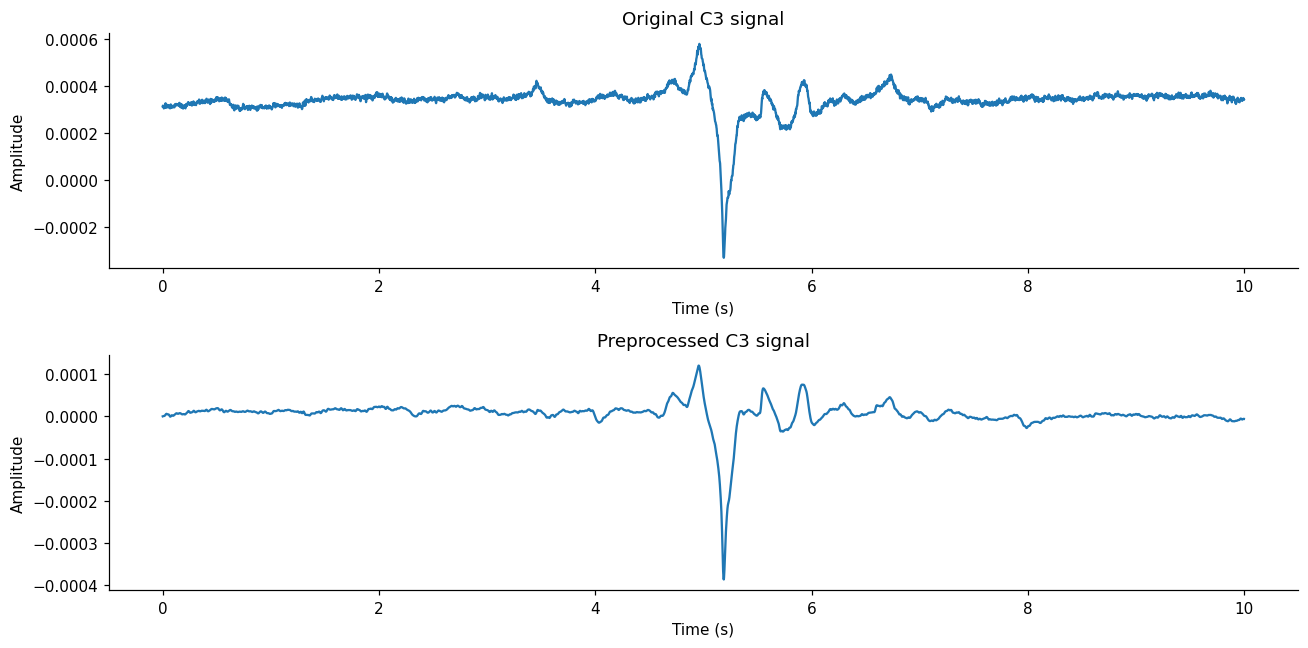


Condition: A
Original data:
- Sampling rate: 500.0 Hz
- Duration: 1030.0 seconds
- Channels: 8

Preprocessed data:
- Sampling rate: 500.0 Hz
- Duration: 1030.0 seconds
- Channels: 8


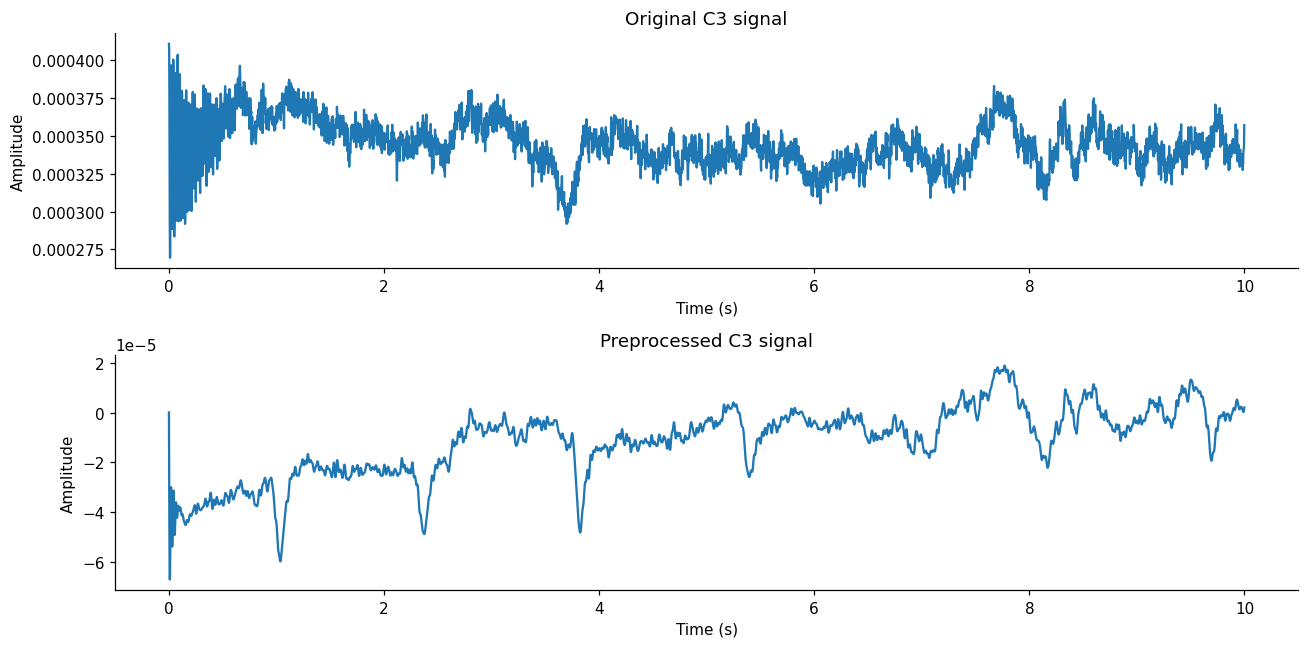


Condition: V
Original data:
- Sampling rate: 500.0 Hz
- Duration: 1024.0 seconds
- Channels: 8

Preprocessed data:
- Sampling rate: 500.0 Hz
- Duration: 1024.0 seconds
- Channels: 8


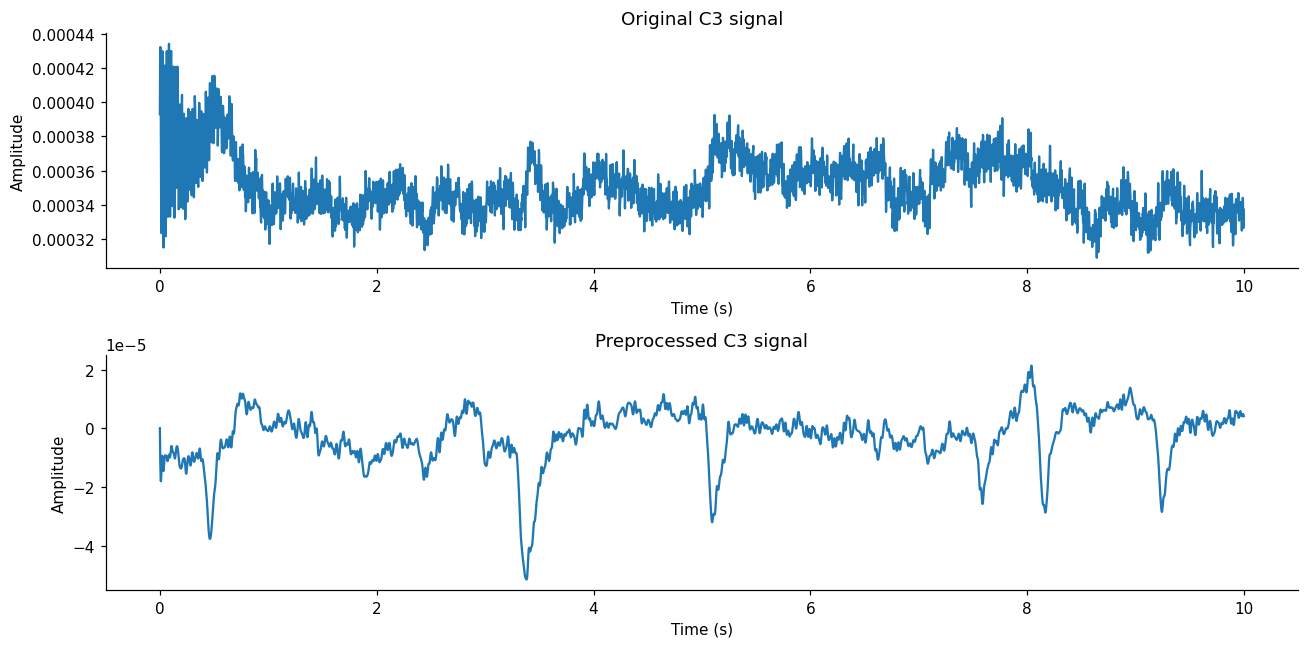

In [114]:
# %% Quick check of raw vs preprocessed data
if isinstance(raws, dict):
    print("\nComparison of raw vs preprocessed data:")
    print("-" * 50)
    for key in raws:
        raw_orig, _, _ = raws[key]
        raw_filtered, _, _ = raw_fs[key]
        
        print(f"\nCondition: {key}")
        print("Original data:")
        print(f"- Sampling rate: {raw_orig.info['sfreq']} Hz")
        print(f"- Duration: {raw_orig.times[-1]:.1f} seconds")
        print(f"- Channels: {len(raw_orig.ch_names)}")
        
        print("\nPreprocessed data:")
        print(f"- Sampling rate: {raw_filtered.info['sfreq']} Hz")
        print(f"- Duration: {raw_filtered.times[-1]:.1f} seconds")
        print(f"- Channels: {len(raw_filtered.ch_names)}")
        
        # Plot a short segment (first 10 seconds) of one channel for comparison
        ch_name = "C3"  # Using C3 as it's important for motor imagery
        if ch_name in raw_orig.ch_names and ch_name in raw_filtered.ch_names:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
            
            # Original data
            start, stop = raw_orig.time_as_index([0, 10])
            data_orig, times = raw_orig[raw_orig.ch_names.index(ch_name), start:stop]
            ax1.plot(times, data_orig.T)
            ax1.set_title(f'Original {ch_name} signal')
            ax1.set_xlabel('Time (s)')
            ax1.set_ylabel('Amplitude')
            
            # Filtered data
            start, stop = raw_filtered.time_as_index([0, 10])
            data_filt, times = raw_filtered[raw_filtered.ch_names.index(ch_name), start:stop]
            ax2.plot(times, data_filt.T)
            ax2.set_title(f'Preprocessed {ch_name} signal')
            ax2.set_xlabel('Time (s)')
            ax2.set_ylabel('Amplitude')
            
            plt.tight_layout()
            plt.show()
else:
    print("\nComparison of raw vs preprocessed data:")
    print("-" * 50)
    print("\nOriginal data:")
    print(f"- Sampling rate: {raw.info['sfreq']} Hz")
    print(f"- Duration: {raw.times[-1]:.1f} seconds")
    print(f"- Channels: {len(raw.ch_names)}")
    
    print("\nPreprocessed data:")
    print(f"- Sampling rate: {raw_f.info['sfreq']} Hz")
    print(f"- Duration: {raw_f.times[-1]:.1f} seconds")
    print(f"- Channels: {len(raw_f.ch_names)}")
    
    # Plot comparison
    ch_name = "C3"
    if ch_name in raw.ch_names and ch_name in raw_f.ch_names:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
        
        # Original data
        start, stop = raw.time_as_index([0, 10])
        data_orig, times = raw[raw.ch_names.index(ch_name), start:stop]
        ax1.plot(times, data_orig.T)
        ax1.set_title(f'Original {ch_name} signal')
        ax1.set_xlabel('Time (s)')
        ax1.set_ylabel('Amplitude')
        
        # Filtered data
        start, stop = raw_f.time_as_index([0, 10])
        data_filt, times = raw_f[raw_f.ch_names.index(ch_name), start:stop]
        ax2.plot(times, data_filt.T)
        ax2.set_title(f'Preprocessed {ch_name} signal')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Amplitude')
        
        plt.tight_layout()
        plt.show()

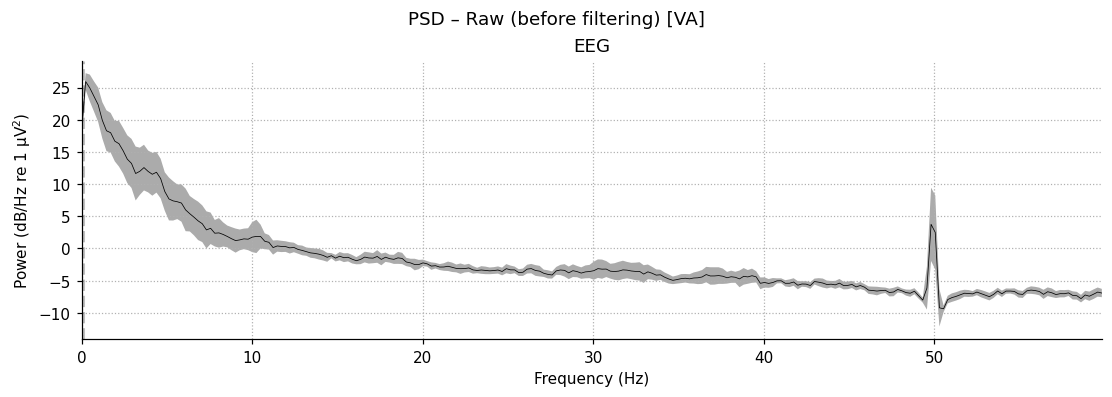

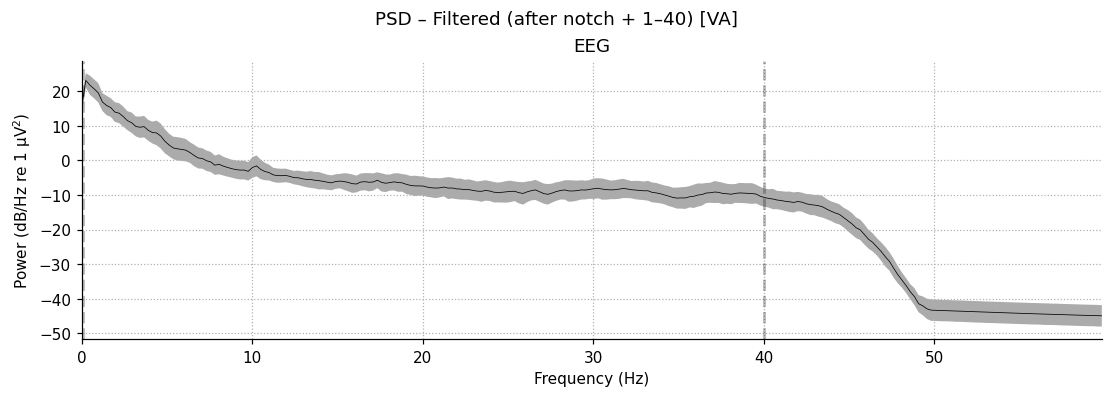

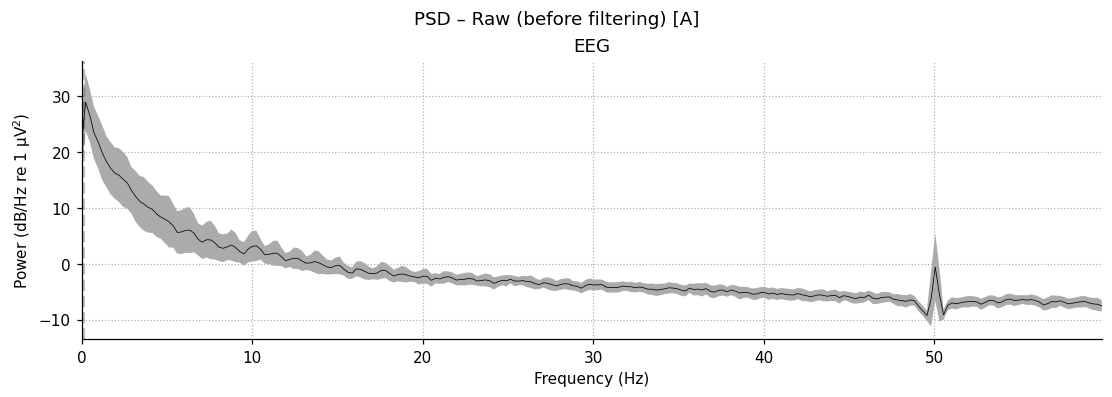

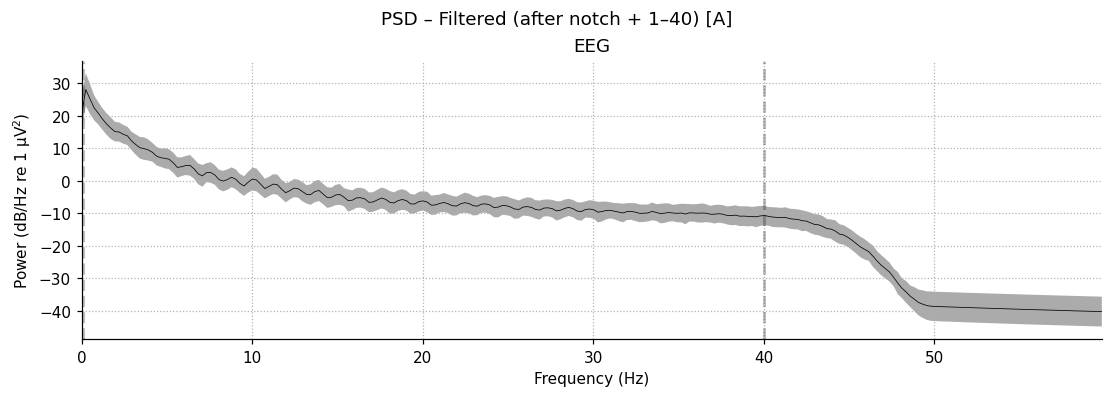

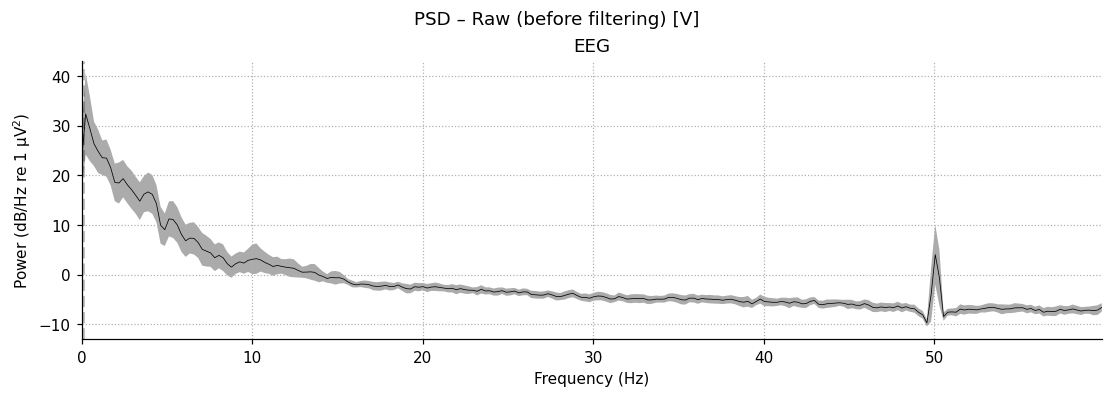

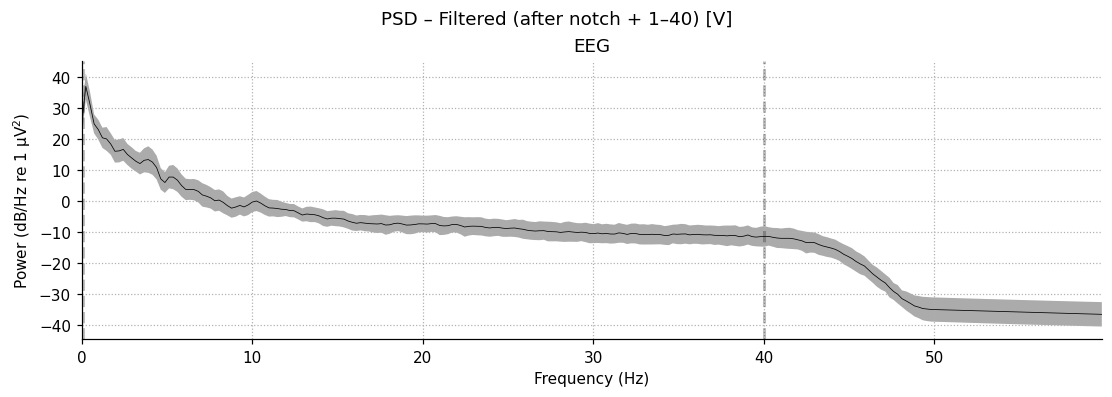

In [115]:
if isinstance(raw_fs, dict):
    # Handle multiple datasets
    for key, (raw_f_data, _, _) in raw_fs.items():        
        # Optional quick PSD overlay (before vs after)
        raw_orig, _, _ = raws[key]
        fig = raw_orig.plot_psd(average=True, fmax=60, show=False)
        fig.suptitle(f"PSD – Raw (before filtering) [{key}]")
        plt.show(fig)
        plt.close(fig)
        
        fig = raw_f_data.plot_psd(average=True, fmax=60, show=False)
        fig.suptitle(f"PSD – Filtered (after notch + 1–40) [{key}]")
        plt.show(fig)
        plt.close(fig)
else:
    # Original single dataset handling
    # Optional quick PSD overlay (before vs after)
    fig = raw.plot_psd(average=True, fmax=60, show=False)
    fig.suptitle("PSD – Raw (before filtering)")
    plt.show(fig)
    plt.close(fig)

    fig = raw_f.plot_psd(average=True, fmax=60, show=False)
    fig.suptitle("PSD – Filtered (after notch + 1–40)")
    plt.show(fig)
    plt.close(fig)

## ICA

ICA configs

In [116]:
# ICA configs
ASR_CUTOFF = 20.0

ICA_METHOD = "infomax"                  # "infomax", "picard", or "fastica"
ICA_VARIANCE = 0.99                     # keep comps to explain 99% variance
DECIM = 3
RAND_SEED = 97

ICLABEL_THRESH = dict(eye=0.90, muscle=0.90, line=0.90)  # EEGLAB-like cutoffs

# Initialize dictionaries for ICA-processed data and ICA objects
if isinstance(raw_fs, dict):
    raw_icas = raw_fs.copy()
    icas = {}
else:
    raw_icas = raw_f.copy()

ASR

In [117]:
# ---- Optional ASR (Clean Rawdata-like) ----
try:
    import asrpy  # ← use the package namespace
    
    if isinstance(raw_icas, dict):
        # Process each dataset
        for key in raw_icas:
            print(f"\nApplying ASR to {key} dataset...")
            raw_ica, events, event_id = raw_icas[key]
            
            asr = asrpy.ASR(sfreq=raw_ica.info["sfreq"], cutoff=ASR_CUTOFF)
            asr.fit(raw_ica, picks="eeg")
            raw_ica = asr.transform(raw_ica, picks="eeg")
            
            raw_icas[key] = (raw_ica, events, event_id)
            print(f"ASR completed for {key}")
            
            # Report
            if report is not None:
                report.add_raw(raw_ica, title=f"Step 2 – After ASR ({key}, cutoff={ASR_CUTOFF})", psd=True)
    else:
        # Original single dataset processing
        print("\nApplying ASR ...")
        asr = asrpy.ASR(sfreq=raw_icas.info["sfreq"], cutoff=ASR_CUTOFF)
        asr.fit(raw_icas, picks="eeg")
        raw_icas = asr.transform(raw_icas, picks="eeg")

        if report is not None:
            report.add_raw(raw_icas, title=f"Step 2 – After ASR (cutoff={ASR_CUTOFF})", psd=True)

except Exception as e:
    print("ASR not available; skipping. Reason:", e)


Applying ASR to VA dataset...
ASR completed for VA

Applying ASR to A dataset...
ASR completed for A

Applying ASR to V dataset...
ASR completed for V


IC decompose

In [118]:
print(f"Fitting ICA ({ICA_METHOD}) ...")
fit_params = {"extended": True} if ICA_METHOD == "infomax" else None  # EEGLAB-style extended Infomax

if isinstance(raw_icas, dict):
    for key, (raw_ica, events, event_id) in raw_icas.items():
        print(f"\nProcessing {key} dataset...")
        # Initialize ICA for this dataset
        ica = ICA(
            method=ICA_METHOD,
            n_components=ICA_VARIANCE,
            random_state=RAND_SEED,
            max_iter="auto",
            fit_params=fit_params,
        )
        
        # Fit ICA
        ica.fit(
            raw_ica,
            picks="eeg",
            decim=DECIM,
            reject_by_annotation=True,
            verbose="WARNING",
        )
        print(f"ICA for {key}:")
        print(ica)
        
        # Store ICA object and copy of raw data
        icas[key] = ica
else:
    # Original single dataset processing
    ica = ICA(
        method=ICA_METHOD,
        n_components=ICA_VARIANCE,
        random_state=RAND_SEED,
        max_iter="auto",
        fit_params=fit_params,
    )
    
    ica.fit(
        raw_ica,
        picks="eeg",
        decim=DECIM,
        reject_by_annotation=True,
        verbose="WARNING",
    )
    print(ica)
    icas['single'] = ica

Fitting ICA (infomax) ...

Processing VA dataset...
ICA for VA:
<ICA | raw data decomposition, method: infomax (fit in 500 iterations on 168500 samples), 7 ICA components (8 PCA components available), channel types: eeg, no sources marked for exclusion>

Processing A dataset...
ICA for A:
<ICA | raw data decomposition, method: infomax (fit in 500 iterations on 171667 samples), 7 ICA components (8 PCA components available), channel types: eeg, no sources marked for exclusion>

Processing V dataset...
ICA for V:
<ICA | raw data decomposition, method: infomax (fit in 500 iterations on 170667 samples), 7 ICA components (8 PCA components available), channel types: eeg, no sources marked for exclusion>


ICLabel

In [119]:
# Setup variables for ICLabel
excludes = {}
probs = {}
used_iclabel = False

In [120]:
# ---- Select artifact ICs (ICLabel first, robust fallbacks) ----
from mne_icalabel import label_components

def process_dataset(raw_data, ica):
    exclude = []
    # 1) Try ICLabel on a 1–100 Hz COPY (recommended by ICLabel)
    sfreq = float(raw_data.info["sfreq"])
    nyq = sfreq / 2.0
    ic_hi = min(100.0, nyq - 1.0)   # e.g., 79.0 for EEGBCI (160 Hz)
    raw_data_temp = raw_data.copy().filter(1.0, ic_hi, picks="eeg", verbose="ERROR")
    ic_labels = label_components(raw_data_temp, ica, method="iclabel")
    
    # ICLabel order: ['brain','muscle','eye','heart','line_noise','channel_noise','other']
    EYE_T, MUS_T, LINE_T = ICLABEL_THRESH["eye"], ICLABEL_THRESH["muscle"], ICLABEL_THRESH["line"]
    labels = ic_labels['labels']
    probs = ic_labels['y_pred_proba']
    
    exclude_idx = [
        idx for idx, label in enumerate(labels) if label not in ["brain", "other"]
    ]
    
    print("Probabilities and labels:", probs, labels)
    for i in exclude_idx:
        if labels[i] == "eye blink":
            if probs[i] >= EYE_T:
                exclude.append(i)
        elif labels[i] == "muscle artifact":
            if probs[i] >= MUS_T:
                exclude.append(i)
        elif labels[i] == "line_noise":
            if probs[i] >= LINE_T:
                exclude.append(i)
    exclude = sorted(set(exclude))
    return exclude, probs

if isinstance(raw_icas, dict):
    for key in raw_icas:
        print(f"\nProcessing ICLabel for {key} dataset...")
        (raw_data, events, event_id)  = raw_icas[key]
        ica = icas[key]
        excludes[key], probs[key] = process_dataset(raw_data, ica)
        print(f"ICLabel picked components for {key}:", excludes[key])
else:
    raw_data = raw_ica
    ica = icas['single']
    excludes['single'], probs['single'] = process_dataset(raw_data, ica)
    print("ICLabel picked components:", excludes['single'])


Processing ICLabel for VA dataset...


C:\Users\user\AppData\Local\Temp\ipykernel_35532\484955868.py:11: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_data_temp, ica, method="iclabel")


Probabilities and labels: [0.88217247 0.7276104  0.6025801  0.9722977  0.8130081  0.99051255
 0.82220197] ['brain', 'brain', 'brain', 'brain', 'eye blink', 'brain', 'brain']
ICLabel picked components for VA: []

Processing ICLabel for A dataset...


C:\Users\user\AppData\Local\Temp\ipykernel_35532\484955868.py:11: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_data_temp, ica, method="iclabel")


Probabilities and labels: [0.8505409  0.81583166 0.9768113  0.75549245 0.8157247  0.9463748
 0.9685    ] ['brain', 'brain', 'eye blink', 'other', 'brain', 'brain', 'brain']
ICLabel picked components for A: [2]

Processing ICLabel for V dataset...


C:\Users\user\AppData\Local\Temp\ipykernel_35532\484955868.py:11: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(raw_data_temp, ica, method="iclabel")


Probabilities and labels: [0.9466624  0.76193225 0.9508276  0.99267775 0.9071803  0.85393214
 0.86741865] ['brain', 'brain', 'brain', 'eye blink', 'brain', 'brain', 'brain']
ICLabel picked components for V: [3]


Label by correlation to Frontal channels

In [121]:
# ---- Select artifact ICs (correlation-based fallbacks) ----
import numpy as np
from mne.preprocessing import find_eog_events
from scipy.stats import kurtosis

def find_detector_channel(raw_data):
    # Case-insensitive channel name helper
    name_map = {c.lower(): c for c in raw_data.ch_names}
    wanted = ["fpz","fp1","fp2","afz","af7","af8","fz","f1","f2"]
    proxies = [name_map[w] for w in wanted if w in name_map]
    
    # If none of the typical frontals exist, auto-pick a "blink detector"
    detector = None
    if proxies:
        detector = proxies[0]
    else:
        eeg_picks = mne.pick_types(raw_data.info, eeg=True)
        tmp = raw_data.copy().filter(1.0, 10.0, picks=eeg_picks, verbose="ERROR")
        X = tmp.get_data(picks=eeg_picks)
        k = kurtosis(X, axis=1, fisher=True, nan_policy="omit")
        detector = raw_data.ch_names[eeg_picks[int(np.nanargmax(np.abs(k)))]]
        print(f"No standard frontal labels found; using kurtosis-based detector: {detector}")
    return detector

def find_blinks_and_correlations(raw_data, raw_f, ica, detector):
    exclude = []
    
    # (A) Event-based blink epochs from the detector channel
    try:
        eog_events = find_eog_events(raw_data, ch_name=detector)
        print(f"Found {len(eog_events)} blink-like events on '{detector}'")
        if len(eog_events):
            eog_epochs = mne.Epochs(raw_data, eog_events, event_id=998, tmin=-0.5, tmax=0.5, 
                                  baseline=(None, 0), picks="eeg", preload=True, reject_by_annotation=True)
            print(eog_epochs)
            bads_ev, _ = ica.find_bads_eog(
                eog_epochs, ch_name=detector, measure="correlation",
                l_freq=1., h_freq=10., reject_by_annotation=True
            )
            exclude.extend(bads_ev)
            print("Event-based EOG picks:", sorted(set(bads_ev)))
    except Exception as ee:
        print("Blink-event fallback failed:", ee)

    # (B) Correlation fallback: IC sources vs detector signal
    try:
        # Work from ONE common, band-limited copy
        raw_corr = raw_f.copy().load_data()
        raw_corr.pick_types(eeg=True)                      # match ICA training picks
        raw_corr.filter(1., 10., verbose="ERROR")          # blink band

        # Sources and detector from the SAME time base
        src = ica.get_sources(raw_corr).get_data()         # (n_comp, n_times)
        det_sig = raw_corr.copy().pick_channels([detector]).get_data()[0]  # (n_times,)

        # Align lengths just in case (e.g., tiny edge differences)
        n = min(src.shape[1], det_sig.size)
        if src.shape[1] != n or det_sig.size != n:
            print(f"Aligning lengths: src={src.shape[1]} det={det_sig.size} -> {n}")
        src = src[:, :n]
        det_sig = det_sig[:n]

        # Correlation (faster & safer than corrcoef in a loop)
        def pearson1d(a, b):
            a = a - a.mean(); b = b - b.mean()
            denom = np.sqrt((a*a).sum() * (b*b).sum())
            return 0.0 if denom == 0 else float((a*b).sum() / denom)

        cors = np.array([pearson1d(s, det_sig) for s in src])
        thr = 0.45
        bads_corr = list(np.flatnonzero(np.abs(cors) >= thr))
        exclude.extend(bads_corr)
        print(f"Correlation-based picks (|r| ≥ {thr:.2f}):", sorted(set(bads_corr)))
    except Exception as ec:
        print("Correlation fallback failed:", ec)

    # (C) Optional: ECG via CTPS (works without ECG channel sometimes)
    try:
        bads_ecg, _ = ica.find_bads_ecg(raw_data, method="ctps", threshold="auto")
        exclude.extend(bads_ecg)
        if bads_ecg:
            print("ECG-like picks (CTPS):", sorted(set(bads_ecg)))
    except Exception:
        pass

    return sorted(set(exclude))

if isinstance(raw_fs, dict):
    for key in raw_icas:
        print(f"\nProcessing correlation fallbacks for {key} dataset...")
        (raw_data, events, event_id)  = raw_icas[key]
        ica = icas[key]
        
        detector = find_detector_channel(raw_data)
        fallback_exclude = find_blinks_and_correlations(raw_data, raw_fs[key][0], ica, detector)

        # Combine with ICLabel results
        excludes[key].extend(fallback_exclude)
        excludes[key] = sorted(set(excludes[key]))
        print(f"Final components to exclude for {key}:", excludes[key])
else:
    detector = find_detector_channel(raw_ica)
    fallback_exclude = find_blinks_and_correlations(raw_ica, raw_f, icas['single'], detector)
    
    # Combine with ICLabel results
    excludes['single'].extend(fallback_exclude)
    excludes['single'] = sorted(set(excludes['single']))
    print("Final components to exclude:", excludes['single'])


Processing correlation fallbacks for VA dataset...
Found 86 blink-like events on 'Fp1'
<Epochs | 85 events (all good), -0.5 – 0.5 s (baseline -0.5 – 0 s), ~2.6 MiB, data loaded,
 '998': 85>
Event-based EOG picks: []
Correlation-based picks (|r| ≥ 0.45): [np.int64(0), np.int64(5)]
Final components to exclude for VA: [np.int64(0), np.int64(5)]

Processing correlation fallbacks for A dataset...
Found 353 blink-like events on 'Fp1'
<Epochs | 352 events (all good), -0.5 – 0.5 s (baseline -0.5 – 0 s), ~10.8 MiB, data loaded,
 '998': 352>
Event-based EOG picks: []
Correlation-based picks (|r| ≥ 0.45): [np.int64(0)]
Final components to exclude for A: [np.int64(0), 2]

Processing correlation fallbacks for V dataset...
Found 513 blink-like events on 'Fp1'
<Epochs | 511 events (all good), -0.5 – 0.5 s (baseline -0.5 – 0 s), ~15.6 MiB, data loaded,
 '998': 511>
Event-based EOG picks: []
Correlation-based picks (|r| ≥ 0.45): [np.int64(0), np.int64(5)]
Final components to exclude for V: [np.int64(0

In [122]:
# Apply ICA exclusions to all datasets
if isinstance(raw_icas, dict):
    for key in raw_icas:
        print(f"\nApplying ICA exclusions to {key} dataset...")
        ica = icas[key]
        ica.exclude = excludes[key]
        
        # Create a copy of the filtered data and apply ICA
        raw_ica = raw_fs[key][0].copy()  # Get raw_f from the tuple
        ica.apply(raw_ica)
        
        # Store the ICA-processed data along with its events and event_id
        raw_icas[key] = (raw_ica, raw_fs[key][1], raw_fs[key][2])
        print(f"Applied ICA with {len(excludes[key])} excluded components for {key}")
else:
    # Original single dataset processing
    ica = icas['single']
    ica.exclude = excludes['single']
    raw_ica = raw_f.copy()
    ica.apply(raw_ica)
    raw_icas['single'] = (raw_ica, events, event_id)
    print(f"Applied ICA with {len(excludes['single'])} excluded components")


Applying ICA exclusions to VA dataset...
Applied ICA with 2 excluded components for VA

Applying ICA exclusions to A dataset...
Applied ICA with 2 excluded components for A

Applying ICA exclusions to V dataset...
Applied ICA with 3 excluded components for V


## Epoch around events


In [123]:
# %% Epoching
if isinstance(raw_icas, dict):
    epochs = {}
    for key in raw_icas:    
        raw_f, events, event_id = raw_icas[key]
        print(f"\nEpoching {key} dataset ...")
        picks = mne.pick_types(raw_f.info, eeg=True, ecog=True, exclude='bads')
        epochs[key] = mne.Epochs(raw_f, events, event_id=event_id, tmin=tmin - 0.5, tmax=tmax + 0.5,
                            baseline=None, picks=picks, preload=True, detrend=1)
        print(epochs)
        # epochs.plot(block=False)  
else:
    print("\nEpoching dataset ...")
    picks = mne.pick_types(raw_f.info, eeg=True, ecog=True, exclude='bads')
    epochs = mne.Epochs(raw_f, events, event_id=event_id, tmin=tmin - 0.5, tmax=tmax + 0.5,
                        baseline=None, picks=picks, preload=True, detrend=1)
    print(epochs)
    # epochs.plot(block=False)


Epoching VA dataset ...
{'VA': <Epochs | 60 events (all good), -4.5 – 9.5 s (baseline off), ~25.7 MiB, data loaded,
 'left': 30
 'right': 30>}

Epoching A dataset ...
{'VA': <Epochs | 60 events (all good), -4.5 – 9.5 s (baseline off), ~25.7 MiB, data loaded,
 'left': 30
 'right': 30>, 'A': <Epochs | 61 events (all good), -4.5 – 9.5 s (baseline off), ~26.1 MiB, data loaded,
 'left': 30
 'right': 31>}

Epoching V dataset ...
{'VA': <Epochs | 60 events (all good), -4.5 – 9.5 s (baseline off), ~25.7 MiB, data loaded,
 'left': 30
 'right': 30>, 'A': <Epochs | 61 events (all good), -4.5 – 9.5 s (baseline off), ~26.1 MiB, data loaded,
 'left': 30
 'right': 31>, 'V': <Epochs | 60 events (all good), -4.5 – 9.5 s (baseline off), ~25.7 MiB, data loaded,
 'left': 30
 'right': 30>}


## AutoReject


AutoReject cleaning for VA dataset ...
Running autoreject on ch_type=eeg




Estimated consensus=0.40 and n_interpolate=1
(60, 8) epochs x channels
Dropped 4 / 60 epochs


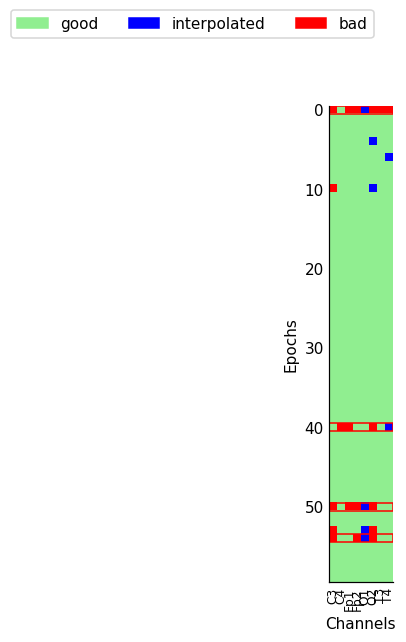

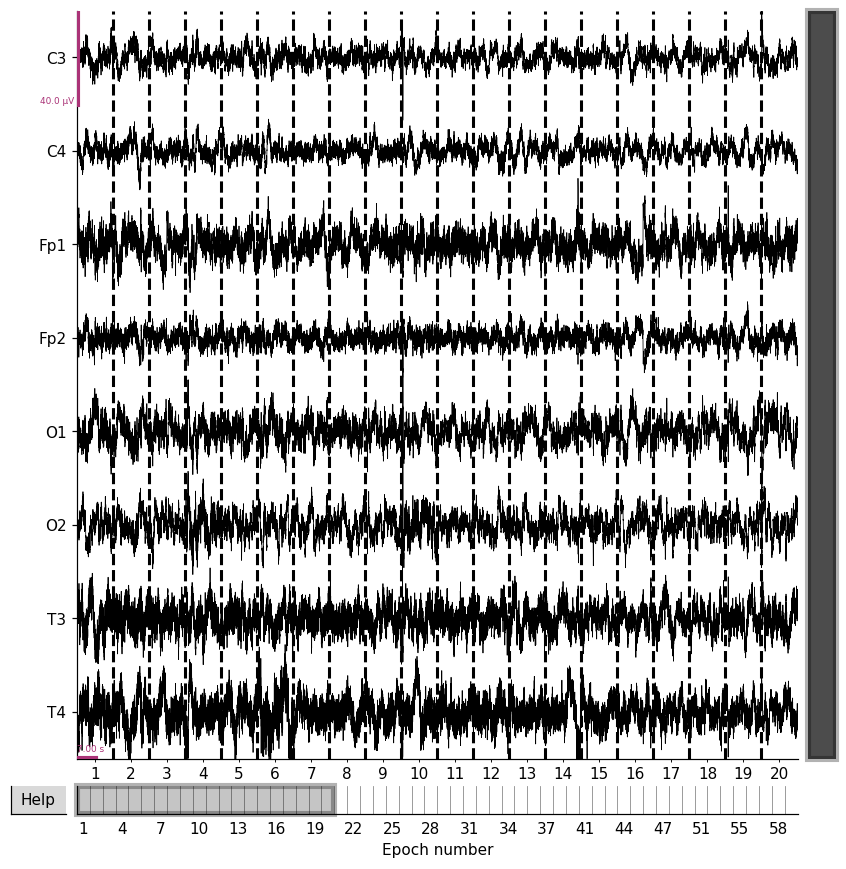

C:\Users\user\AppData\Local\Temp\ipykernel_35532\2823839398.py:31: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  epochs_cleaned[key].interpolate_bads()   # should already be clean, but harmless if called



AutoReject cleaning for A dataset ...
Running autoreject on ch_type=eeg


d:\user\Files_without_backup\MSc_Project\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\user\Files_without_backup\MSc_Project\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)






Estimated consensus=0.90 and n_interpolate=7
(61, 8) epochs x channels
Dropped 2 / 61 epochs


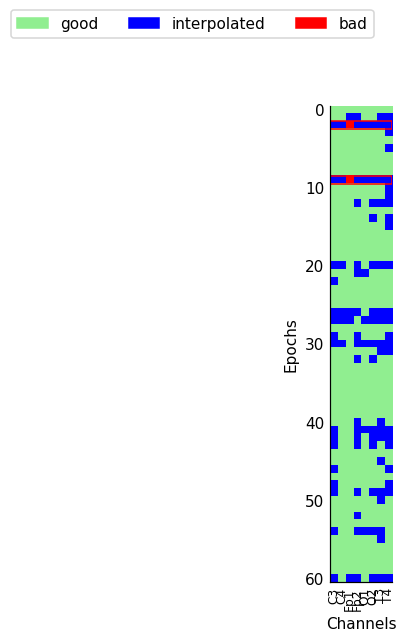

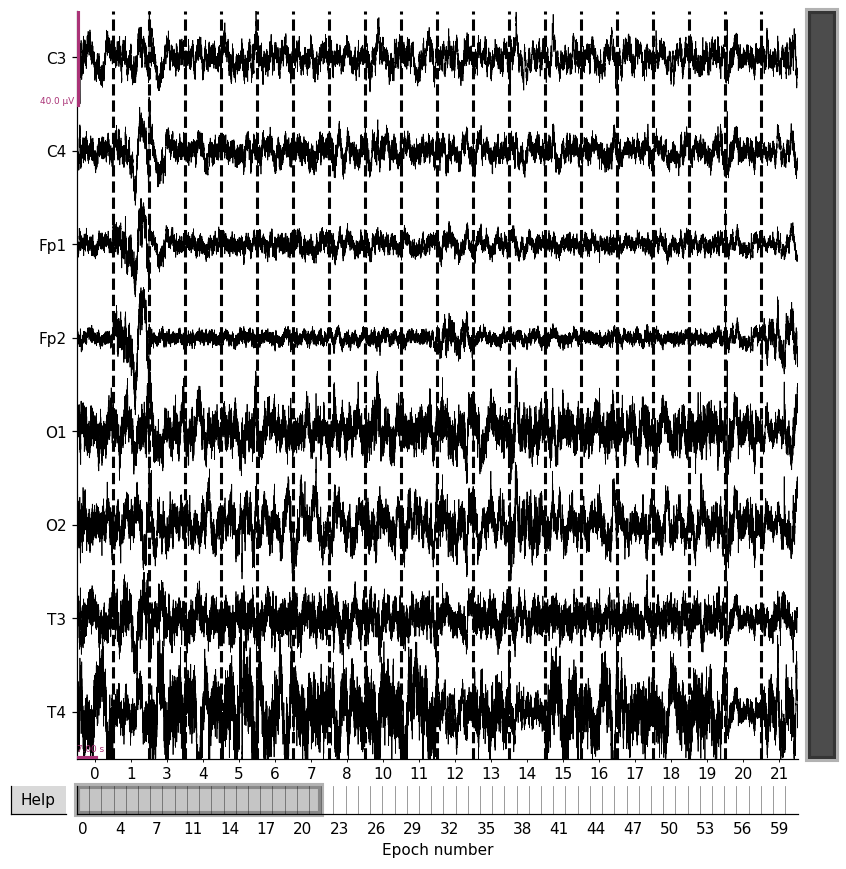

C:\Users\user\AppData\Local\Temp\ipykernel_35532\2823839398.py:31: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  epochs_cleaned[key].interpolate_bads()   # should already be clean, but harmless if called



AutoReject cleaning for V dataset ...
Running autoreject on ch_type=eeg


d:\user\Files_without_backup\MSc_Project\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
d:\user\Files_without_backup\MSc_Project\.venv\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)






Estimated consensus=0.60 and n_interpolate=1
(60, 8) epochs x channels
Dropped 4 / 60 epochs


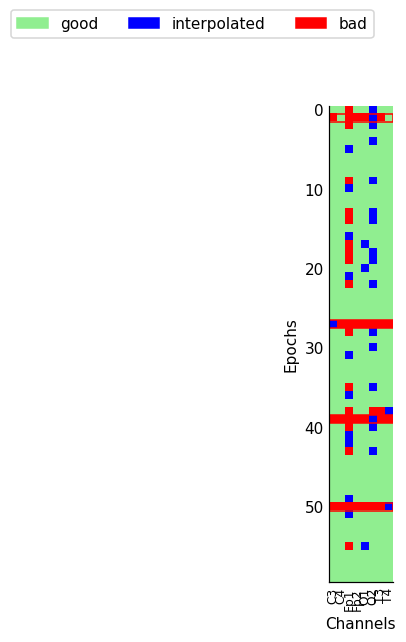

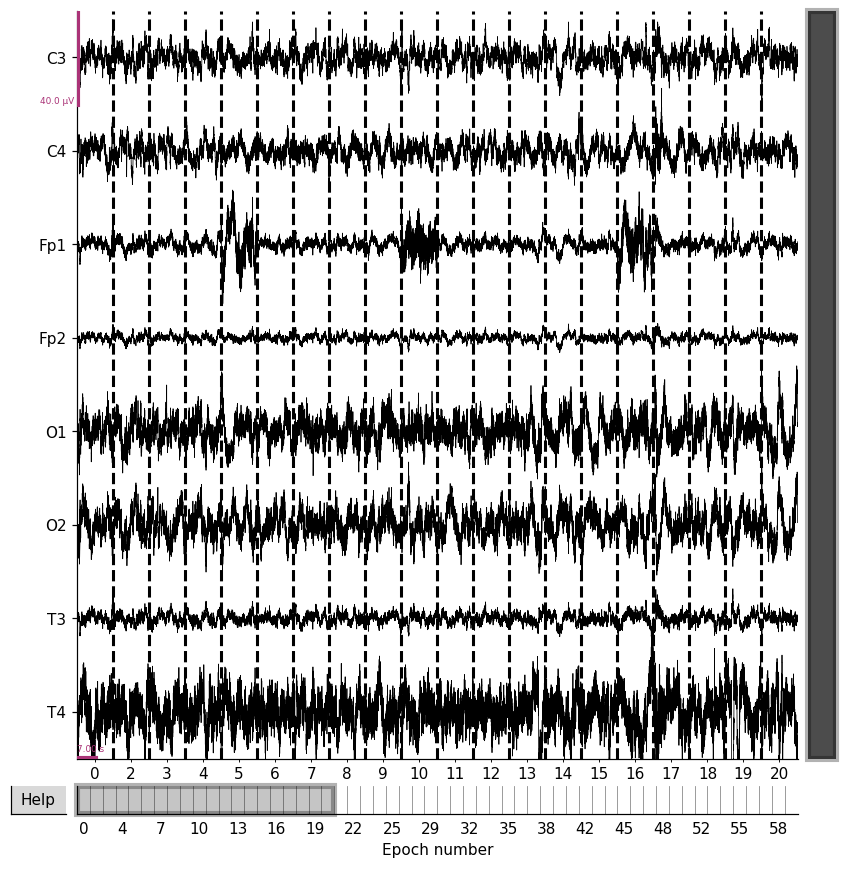

C:\Users\user\AppData\Local\Temp\ipykernel_35532\2823839398.py:31: RuntimeWarning: No bad channels to interpolate. Doing nothing...
  epochs_cleaned[key].interpolate_bads()   # should already be clean, but harmless if called


In [124]:
if isinstance(epochs, dict):
    epochs_cleaned = {}
    reject_logs = {}
    for key in epochs:
        print(f"\nAutoReject cleaning for {key} dataset ...")
        # (Optional) RANSAC first: finds consistently bad sensors and interpolates them within epochs
        # ransac = Ransac(random_state=97, n_jobs=-1, verbose='tqdm')  # defaults are fine
        # epochs_r = ransac.fit_transform(epochs)
        epochs_r = epochs[key].copy()  # use original epochs if not using RANSAC

        # AutoReject learns thresholds, interpolates bad channels, drops hopeless epochs ---
        ar = AutoReject(
            n_jobs=-1,
            cv=5,                           # cross-validation folds
            random_state=97,
            verbose='tqdm'
            # You can tune these if needed:
            # n_interpolate=[1, 2, 4, 8, 16],              # how many channels can be interpolated per epoch
            # consensus=np.linspace(0.1, 0.6, 6)           # fraction of sensors that must agree a sample is bad
        )
        # epochs_clean
        epochs_cleaned[key] = ar.fit_transform(epochs_r)       # main step
        reject_logs[key] = ar.get_reject_log(epochs_r)        # what got rejected/interpolated

        print(reject_logs[key].labels.shape, "epochs x channels")
        print(f"Dropped {reject_logs[key].bad_epochs.sum()} / {len(epochs_r)} epochs")

        # Optional quick sanity checks:
        reject_logs[key].plot()                 # heatmap of bad channels/epochs
        epochs_cleaned[key].plot()               # scroll a few trials
        epochs_cleaned[key].interpolate_bads()   # should already be clean, but harmless if called

else:
    # (Optional) RANSAC first: finds consistently bad sensors and interpolates them within epochs
    # ransac = Ransac(random_state=97, n_jobs=-1, verbose='tqdm')  # defaults are fine
    # epochs_r = ransac.fit_transform(epochs)
    epochs_r = epochs.copy()  # use original epochs if not using RANSAC

    # AutoReject learns thresholds, interpolates bad channels, drops hopeless epochs ---
    ar = AutoReject(
        n_jobs=-1,
        cv=5,                         # cross-validation folds
        random_state=97,
        verbose='tqdm'
        # You can tune these if needed:
        # n_interpolate=[1, 2, 4, 8, 16],              # how many channels can be interpolated per epoch
        # consensus=np.linspace(0.1, 0.6, 6)           # fraction of sensors that must agree a sample is bad
    )
    # epochs_clean
    epochs_clean = ar.fit_transform(epochs_r)       # main step
    reject_log = ar.get_reject_log(epochs_r)        # what got rejected/interpolated

    print(reject_log.labels.shape, "epochs x channels")
    print(f"Dropped {reject_log.bad_epochs.sum()} / {len(epochs_r)} epochs")

    # Optional quick sanity checks:
    reject_log.plot()                 # heatmap of bad channels/epochs
    epochs_clean.plot()               # scroll a few trials
    epochs_clean.interpolate_bads()   # should already be clean, but harmless if called

In [125]:
# BLOCK −1 — Input adapter (run this first)
# Purpose: turn epochs_cleaned={'V': Epochs, 'A': Epochs, 'VA': Epochs}
# into a single `epochs` with metadata columns: 'modality', 'hand', 'block'

import numpy as np
import pandas as pd
import mne
from collections import Counter

# --- 0) Basic checks
assert isinstance(epochs_cleaned, dict), "epochs_cleaned must be a dict like {'V': Epochs, 'A': Epochs, 'VA': Epochs}"
modalities_in = [k for k in ['V','A','VA'] if k in epochs_cleaned]
assert len(modalities_in) >= 1, "epochs_cleaned must include at least one of: 'V', 'A', 'VA'"

# --- 1) Copy & equalize channels across all provided modalities
eps_list = [epochs_cleaned[k].copy() for k in modalities_in]
mne.channels.equalize_channels(eps_list)   # inplace: keeps intersection and same order across all

# --- 2) Verify same sfreq and time span
sfreqs = {float(e.info['sfreq']) for e in eps_list}
tmins  = {np.round(float(e.tmin), 3) for e in eps_list}
tmaxs  = {np.round(float(e.tmax), 3) for e in eps_list}
assert len(sfreqs) == 1 and len(tmins) == 1 and len(tmaxs) == 1, \
    f"Mismatched sfreq/times across modalities: sfreqs={sfreqs}, tmin={tmins}, tmax={tmaxs}"
sfreq = next(iter(sfreqs))
tmin  = next(iter(tmins))
tmax  = next(iter(tmaxs))

# --- 3) Helper to infer 'hand' label per epoch from event codes
def infer_hand_labels(e: mne.Epochs):
    id_map = e.event_id  # {'left': int, 'right': int, ...}
    inv = {v: k for k, v in id_map.items()}
    labels = []
    for code in e.events[:, 2]:
        name = inv.get(int(code), 'unknown')
        if name not in ('left', 'right'):
            lname = str(name).lower()
            if 'left' in lname:
                name = 'left'
            elif 'right' in lname:
                name = 'right'
        labels.append(name)
    return labels

# --- 4) Attach metadata: 'modality' and 'hand' (preserve existing cols if any)
eps_aug = []
for mod, e in zip(modalities_in, eps_list):
    md = e.metadata.copy() if e.metadata is not None else pd.DataFrame(index=np.arange(len(e)))
    md = md.reset_index(drop=True)
    md['modality'] = mod
    md['hand'] = infer_hand_labels(e)
    unexpected = set(md['hand']) - {'left', 'right'}
    assert not unexpected, f"Unexpected hand labels in modality {mod}: {unexpected}"
    assert len(md) == len(e), f"Metadata length mismatch for {mod}: {len(md)} vs {len(e)}"
    # IMPORTANT: in MNE, set metadata by assigning to the property (no set_metadata method)
    e = e.copy()
    e.metadata = md
    eps_aug.append(e)

# --- 5) Concatenate into a single Epochs with metadata preserved
epochs = mne.concatenate_epochs(eps_aug, add_offset=False, on_mismatch='raise')

# --- 6) Ensure required channels exist (C3/C4 needed later)
for ch in ('C3', 'C4'):
    assert ch in epochs.ch_names, f"Required channel {ch} not found after equalization: {epochs.ch_names}"

# --- 7) Create/normalize a 'block' grouping column (for grouped CV).
# If original metadata had 'block', keep it; otherwise, create sequential blocks of ~10 trials within each modality.
if 'block' not in epochs.metadata.columns:
    block = np.empty(len(epochs), dtype=int)
    for mod in modalities_in:
        idx_mod = np.where(epochs.metadata['modality'].values == mod)[0]
        block[idx_mod] = np.arange(len(idx_mod)) // 10  # groups of ~10 within modality
    epochs.metadata['block'] = block

# --- 8) Compact summary
print("✓ Unified `epochs` created")
print(epochs)
print("\nCounts by modality:")
print(epochs.metadata['modality'].value_counts())
print("\nCounts by (modality × hand):")
print(epochs.metadata.groupby(['modality', 'hand']).size())

print(f"\nsfreq={sfreq} Hz | tmin={tmin} s | tmax={tmax} s")


✓ Unified `epochs` created
<EpochsArray | 171 events (all good), -4.5 – 9.5 s (baseline off), ~73.1 MiB, data loaded, with metadata,
 'left': 84
 'right': 87>

Counts by modality:
modality
A     59
V     56
VA    56
Name: count, dtype: int64

Counts by (modality × hand):
modality  hand 
A         left     28
          right    31
V         left     28
          right    28
VA        left     28
          right    28
dtype: int64

sfreq=500.0 Hz | tmin=-4.5 s | tmax=9.5 s


C:\Users\user\AppData\Local\Temp\ipykernel_35532\2660806835.py:61: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  epochs = mne.concatenate_epochs(eps_aug, add_offset=False, on_mismatch='raise')
C:\Users\user\AppData\Local\Temp\ipykernel_35532\2660806835.py:61: RuntimeWarning: The events passed to the Epochs constructor are not chronologically ordered.
  epochs = mne.concatenate_epochs(eps_aug, add_offset=False, on_mismatch='raise')


In [126]:
print(type(epochs))                         # <class 'mne.epochs.Epochs'>
print(isinstance(epochs, mne.Epochs))       # True
print(isinstance(epochs.metadata, pd.DataFrame))  # True
print(epochs)                        # <Epochs | N events, -4.5 – 9.5 s, ...>
epochs.metadata

<class 'mne.epochs.EpochsArray'>
False
True
<EpochsArray | 171 events (all good), -4.5 – 9.5 s (baseline off), ~73.1 MiB, data loaded, with metadata,
 'left': 84
 'right': 87>


,modality,hand,block
0,V,left,0
2,V,left,0
3,V,right,0
4,V,right,0
5,V,right,0
...,...,...,...
177,VA,left,5
178,VA,right,5
179,VA,left,5
180,VA,left,5


In [127]:
type(epochs)

mne.epochs.EpochsArray

# MI ERD/PMBR



In [128]:
# ============================================================
# SINGLE NOTEBOOK CELL — ERD/ERS from TFR (Morlet/Multitaper)
# End-to-end: compute TFR → μ/β @ C3/C4 → baseline −3.5…−0.5 s → % & dB
# → quick-check plots → tidy DataFrame saved
#
# Assumes:
#   - `epochs` is an in-memory mne.Epochs (cleaned), time ≈ −4.5…+9.5 s
#   - epochs.metadata has columns: 'modality' ∈ {'V','A','VA'}, 'hand' ∈ {'left','right'}
#   - channels include 'C3' and 'C4'
# No seaborn used.
# ============================================================

# -----------------------------
# BLOCK 0: Imports & paths
# -----------------------------
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import mne

results_dir = Path("results")
figs_dir = results_dir / "figs"
results_dir.mkdir(parents=True, exist_ok=True)
figs_dir.mkdir(parents=True, exist_ok=True)

print(f"[INFO] MNE: {mne.__version__}")

# -----------------------------
# BLOCK 1: Core TFR -> ERD/ERS (Morlet or Multitaper)
# -----------------------------
def _compute_tfr_epochs(epochs, freqs, method="morlet", n_cycles=None,
                        time_bandwidth=4.0, decim=1, n_jobs=None):
    """
    Compute an EpochsTFR using MNE's newer API if available,
    otherwise fall back to tfr_morlet / tfr_multitaper.

    Returns
    -------
    tfr : mne.time_frequency.EpochsTFR
        shape: (n_epochs, n_channels, n_freqs, n_times) with .data as power
    """
    method = method.lower()
    # sensible defaults per method
    if n_cycles is None:
        if method == "morlet":
            n_cycles = 7
        elif method in ("multitaper", "mtm"):
            n_cycles = np.asarray(freqs) / 2.0
        else:
            raise ValueError("method must be 'morlet' or 'multitaper'")

    # Prefer the newer API if present
    try:
        from mne.time_frequency import compute_tfr  # new in recent MNE
        kwargs = dict(
            freqs=freqs,
            method=method,
            n_cycles=n_cycles,
            average=False,
            use_fft=True,
            decim=decim,
            n_jobs=n_jobs,
            output="power",
        )
        if method in ("multitaper", "mtm"):
            kwargs["time_bandwidth"] = float(time_bandwidth)
        tfr = compute_tfr(epochs, **kwargs)
        return tfr
    except Exception:
        # Fall back to classic APIs (widely available across versions)
        from mne.time_frequency import tfr_morlet, tfr_multitaper
        if method == "morlet":
            tfr = tfr_morlet(
                epochs, freqs=freqs, n_cycles=n_cycles, use_fft=True,
                return_itc=False, average=False, decim=decim, n_jobs=n_jobs,
                output="power"
            )
        else:
            # IMPORTANT: no 'output' kw here for some MNE versions
            tfr = tfr_multitaper(
                epochs, freqs=freqs, n_cycles=n_cycles, time_bandwidth=time_bandwidth,
                use_fft=True, return_itc=False, average=False, decim=decim,
                n_jobs=n_jobs
            )
        return tfr


def erds_timecourse_tfr(
    epochs, picks, band, baseline=(-1.0, 0.0),
    method="morlet",                       # 'morlet' or 'multitaper'
    freqs=None,                            # e.g., np.linspace(8,12,9) for mu, or None to auto
    n_cycles=None,                         # scalar or array-like (per-freq)
    time_bandwidth=4.0,                    # multitaper NW (TW); K ≈ 2*TW - 1
    decim=1, n_jobs=None,
    smooth_ms=0,                           # 0 = no smoothing; for plotting only
    robust=True, trim_s=0.25,              # trim edges to avoid convolution transients
    keep_channels=True,                    # keep C3 and C4 separate for outputs
):
    """
    Compute ERD/ERS timecourses from TFR (Morlet or Multitaper) for a band.

    Returns
    -------
    t : (n_times,) time vector (possibly trimmed)

    ersd_pct_mean : (n_channels, n_times) or (n_times,)
    ersd_pct_sem  : (n_channels, n_times) or (n_times,)
    ersd_db_mean  : (n_channels, n_times) or (n_times,)
    ersd_db_sem   : (n_channels, n_times) or (n_times,)

    ersd_pct_trials : (n_trials, n_channels, n_times) or (n_trials, n_times)
    ersd_db_trials  : (n_trials, n_channels, n_times) or (n_trials, n_times)

    meta : dict with aux info (freqs_used, eff_sfreq, picks_resolved, etc.)
    """
    # 1) Pick channels (can be name, list of names, or index list)
    ep = epochs.copy().pick(picks)
    ch_names = ep.ch_names

    # 2) Define frequency sampling over the band for TFR
    lo, hi = band
    if freqs is None:
        # dense enough for the band
        n_f = int(np.clip(np.round((hi - lo) * 1.5), 6, 30))
        freqs = np.linspace(lo, hi, n_f)

    # 3) Compute TFR (power), keeping trials
    tfr = _compute_tfr_epochs(
        ep, freqs=freqs, method=method, n_cycles=n_cycles,
        time_bandwidth=time_bandwidth, decim=decim, n_jobs=n_jobs
    )
    # tfr.data shape: (n_epochs, n_channels, n_freqs, n_times)
    P = tfr.data
    times = tfr.times
    eff_sfreq = ep.info["sfreq"] / decim

    # 4) Per-trial, per-channel, per-frequency baseline (linear power)
    bmask = (times >= baseline[0]) & (times <= baseline[1])
    if bmask.sum() == 0:
        raise ValueError(
            f"No samples in baseline window {baseline} s. "
            f"TFR time span: [{times[0]:.3f}, {times[-1]:.3f}] s (N={times.size})."
        )
    P0 = P[:, :, :, bmask].mean(axis=3, keepdims=True)  # (n_epochs, n_channels, n_freqs, 1)

    # 5) Band-average in linear domain
    P_band  = P.mean(axis=2)      # (n_epochs, n_channels, n_times)
    P0_band = P0.mean(axis=2)     # (n_epochs, n_channels, 1)

    # 6) Optionally average channels right here if not keeping them
    if not keep_channels:
        P_band  = P_band.mean(axis=1, keepdims=True)   # (n_epochs, 1, n_times)
        P0_band = P0_band.mean(axis=1, keepdims=True)  # (n_epochs, 1, 1)

    # 7) ERD/ERS (% and dB), per trial
    eps = 1e-30
    ersd_pct_trials = 100.0 * (P_band - P0_band) / (P0_band + eps)
    ersd_db_trials  = 10.0 * np.log10((P_band + eps) / (P0_band + eps))  # dB
    if not keep_channels:  # squeeze channel dim if combined
        ersd_pct_trials = ersd_pct_trials[:, 0, :]
        ersd_db_trials  = ersd_db_trials[:,  0, :]

    # 8) Optional smoothing (Savitzky–Golay across time per trial) — for plotting only
    if smooth_ms and smooth_ms > 0:
        win = max(5, int(round(eff_sfreq * smooth_ms / 1000.0)) | 1)  # odd window

        def _smooth_inplace(X):
            if X.ndim == 2:
                for i in range(X.shape[0]):
                    X[i] = savgol_filter(X[i], window_length=win, polyorder=3, mode="interp")
            else:
                for i in range(X.shape[0]):
                    for c in range(X.shape[1]):
                        X[i, c] = savgol_filter(X[i, c], window_length=win, polyorder=3, mode="interp")

        _smooth_inplace(ersd_pct_trials)
        _smooth_inplace(ersd_db_trials)

    # 9) Trim edges to reduce convolution/ringing artifacts
    if trim_s and trim_s > 0:
        keep = (times >= (times[0] + trim_s)) & (times <= (times[-1] - trim_s))
        times = times[keep]
        if ersd_pct_trials.ndim == 2:
            ersd_pct_trials = ersd_pct_trials[:, keep]
            ersd_db_trials  = ersd_db_trials[:,  keep]
        else:
            ersd_pct_trials = ersd_pct_trials[:, :, keep]
            ersd_db_trials  = ersd_db_trials[:,  :, keep]

    # 10) Aggregate across trials (for quick-look plots)
    agg = np.median if robust else np.mean
    if ersd_pct_trials.ndim == 2:
        ersd_pct_mean = agg(ersd_pct_trials, axis=0)                 # (n_times,)
        ersd_db_mean  = agg(ersd_db_trials,  axis=0)
        sem_pct = ersd_pct_trials.std(axis=0, ddof=1) / np.sqrt(max(1, ersd_pct_trials.shape[0]))
        sem_db  = ersd_db_trials .std(axis=0, ddof=1) / np.sqrt(max(1, ersd_db_trials.shape[0]))
    else:
        ersd_pct_mean = agg(ersd_pct_trials, axis=0)                 # (n_channels, n_times)
        ersd_db_mean  = agg(ersd_db_trials,  axis=0)
        sem_pct = ersd_pct_trials.std(axis=0, ddof=1) / np.sqrt(max(1, ersd_pct_trials.shape[0]))
        sem_db  = ersd_db_trials .std(axis=0, ddof=1) / np.sqrt(max(1, ersd_db_trials.shape[0]))

    meta = dict(
        method=method, freqs_used=freqs, eff_sfreq=eff_sfreq,
        picks=picks, picks_resolved=ch_names, band=band, baseline=baseline, decim=decim,
        n_cycles=n_cycles, time_bandwidth=time_bandwidth, robust=robust,
        trimmed_seconds=float(trim_s or 0), keep_channels=keep_channels
    )
    return (times, ersd_pct_mean, sem_pct,
            ersd_db_mean,  sem_db,
            ersd_pct_trials, ersd_db_trials, meta)

# -----------------------------
# BLOCK 2: Plot helpers (lightweight, matplotlib only)
# -----------------------------
def _shade(ax, x0, x1, alpha=0.08):
    ax.axvspan(x0, x1, alpha=alpha, linewidth=0)

def _savgol_maybe(y, window, poly):
    if window is None or window <= 0:
        return y
    w = int(window)
    if w % 2 == 0:
        w += 1
    w = max(5, min(w, len(y) - 1 if (len(y) - 1) % 2 == 1 else len(y) - 2))
    if w < 5 or w >= len(y):
        return y
    try:
        return savgol_filter(y, window_length=w, polyorder=min(poly, w - 1))
    except Exception:
        return y
        

[INFO] MNE: 1.10.0


### Config

In [131]:
# -----------------------------
# BLOCK 3: Config & checks
# -----------------------------
# Parameters
bands = {'mu': (8, 12), 'beta': (13, 30)}
baseline = (-3, -1)        # seconds (must be fully inside epochs.times)
tfr_method = 'morlet'          # 'morlet' or 'multitaper'
morlet_n_cycles = 7
mt_time_bandwidth = 4.0
decim = 1

# For figures only (statistics later should use unsmoothed data)
smooth_figures = True
smooth_ms = 200
eff_sfreq = epochs.info['sfreq'] / decim
print(eff_sfreq)
savgol_window_samples = max(5, int(round(eff_sfreq * smooth_ms / 1000.0)) | 1)  # odd window
savgol_poly = 3

picks = ['C3', 'C4']           # required outputs
assert all(ch in epochs.ch_names for ch in picks), "C3/C4 must be present in epochs."

# Metadata checks
if not (hasattr(epochs, "metadata") and isinstance(epochs.metadata, pd.DataFrame)):
    raise ValueError("epochs.metadata (pandas DataFrame) is required.")
for col in ("modality", "hand"):
    if col not in epochs.metadata.columns:
        raise ValueError(f"epochs.metadata['{col}'] is required but missing.")

# Baseline inside time range
tmin, tmax = float(epochs.times[0]), float(epochs.times[-1])
if not (baseline[0] >= tmin and baseline[1] <= tmax):
    raise ValueError(
        f"Baseline {baseline} s is outside data window "
        f"[{tmin:.3f}, {tmax:.3f}] s. Adjust `baseline` or your epochs."
    )

print("\n[INFO] Trial counts per (modality, hand):")
print(epochs.metadata.value_counts(["modality", "hand"]).sort_index().to_string())

# -----------------------------
# BLOCK 4: Compute ERD/ERS for μ & β using helper (keep channels separate)
# -----------------------------
results = {}  # band_name -> dict
for band_name, band in bands.items():
    t, m_pct, s_pct, m_db, s_db, trials_pct, trials_db, meta = erds_timecourse_tfr(
        epochs, picks=picks, band=band, baseline=baseline,
        method=tfr_method,
        freqs=None,                      # auto grid across band
        n_cycles=(morlet_n_cycles if tfr_method == "morlet" else None),
        time_bandwidth=mt_time_bandwidth,
        decim=decim,
        smooth_ms=0,                     # keep trials unsmoothed (smoothing only in figures)
        robust=True, trim_s=0.25,
        keep_channels=True
    )
    results[band_name] = dict(
        t=t, m_pct=m_pct, s_pct=s_pct, m_db=m_db, s_db=s_db,
        trials_pct=trials_pct, trials_db=trials_db, meta=meta
    )

# Print TFR-derived time range info
t_any = next(iter(results.values()))["t"]
print(f"\n[INFO] ERD/ERS time vector: {t_any[0]:.3f} … {t_any[-1]:.3f} s (N={t_any.size})")

# -----------------------------
# BLOCK 5: Build tidy DataFrame (trial_id, hand, modality, channel, band, measure, time, value)
# -----------------------------
dfs = []
meta_df = epochs.metadata.reset_index(drop=True)[["hand", "modality"]]
n_trials = len(meta_df)

for band_name, payload in results.items():
    t = payload["t"]
    for measure_name, arr in (("percent", payload["trials_pct"]),
                              ("db",      payload["trials_db"])):
        # arr: (n_trials, n_channels, n_times)
        print(f"[INFO] Processing band={band_name}, measure={measure_name}: array shape {arr.shape}")
        if arr.ndim != 3:
            raise RuntimeError("Expected (n_trials, n_channels, n_times); ensure keep_channels=True.")
        n_trials_arr, n_ch, n_times = arr.shape
        # sanity check trials align
        if n_trials_arr != n_trials:
            raise RuntimeError(f"Trials mismatch: metadata={n_trials}, array={n_trials_arr}")
        for ci, ch in enumerate(results[band_name]["meta"]["picks_resolved"]):
            values = arr[:, ci, :].reshape(-1)
            trial_id = np.repeat(np.arange(n_trials, dtype=int), n_times)
            time_rep = np.tile(t, n_trials)
            hand_rep = np.repeat(meta_df["hand"].to_numpy(), n_times)
            mod_rep  = np.repeat(meta_df["modality"].to_numpy(), n_times)
            df = pd.DataFrame({
                "trial_id": trial_id,
                "hand": hand_rep,
                "modality": mod_rep,
                "channel": ch,
                "band": band_name,
                "measure": measure_name,
                "time": time_rep.astype(float),
                "value": values.astype(float),
            })
            dfs.append(df)

df_band = pd.concat(dfs, ignore_index=True)

# Save preview to Parquet (fallback to CSV if Parquet not available)
preview_path_parquet = results_dir / "bandpower_preview.parquet"
preview_path_csv = results_dir / "bandpower_preview.csv"
try:
    subset = df_band.iloc[:1000].copy() if len(df_band) > 1000 else df_band.copy()
    subset.to_parquet(preview_path_parquet, index=False)
    saved_preview_path = preview_path_parquet
except Exception as e:
    print(f"[WARN] Parquet save failed ({e}). Falling back to CSV.")
    subset = df_band.iloc[:1000].copy() if len(df_band) > 1000 else df_band.copy()
    subset.to_csv(preview_path_csv, index=False)
    saved_preview_path = preview_path_csv

print("\n[INFO] df_band head:")
print(df_band.head().to_string(index=False))

# Value ranges
for band_name in bands:
    for measure_name in ("percent", "db"):
        sub = df_band[(df_band["band"] == band_name) & (df_band["measure"] == measure_name) & (df_band["channel"].isin(picks))]
        if len(sub):
            vmin, vmax = float(np.nanmin(sub["value"].to_numpy())), float(np.nanmax(sub["value"].to_numpy()))
            print(f"[RANGE] {band_name:>4s} | {measure_name:7s} | [{vmin:.2f}, {vmax:.2f}]")

print(f"[OK] Preview saved to: {saved_preview_path}")

# -----------------------------
# BLOCK 6: Quick-check plots (overview & by modality×hand) — %ERD only
# -----------------------------
overview_path = figs_dir / "erd_qc_overview.png"
by_modality_path = figs_dir / "erd_qc_by_modality.png"

# Plot A: grand-average %ERD at C3/C4 for μ & β (all trials pooled)
figA, axesA = plt.subplots(nrows=len(bands), ncols=1, figsize=(10, 3.6*len(bands)), sharex=True)
if len(bands) == 1:
    axesA = [axesA]
for ax, band_name in zip(axesA, bands.keys()):
    sub = df_band[
        (df_band["band"] == band_name) &
        (df_band["measure"] == "percent") &
        (df_band["channel"].isin(picks))
    ]
    for ch in picks:
        s = sub[sub["channel"] == ch]
        g = s.groupby("time", as_index=False)["value"].mean().sort_values("time")
        x = g["time"].to_numpy()
        y_raw = g["value"].to_numpy()
        y = _savgol_maybe(y_raw, savgol_window_samples if smooth_figures else 0, savgol_poly)
        ax.plot(x, y_raw, alpha=0.25, lw=1.0, label=f"{ch} raw")
        ax.plot(x, y, lw=2.0, label=f"{ch} smoothed")
    ax.axvline(0, color="k", ls="--", lw=1)
    _shade(ax, baseline[0], baseline[1], alpha=0.08)
    _shade(ax, 0.5, 4.5, alpha=0.06)     # ERD window (illustrative)
    _shade(ax, 6.25, 8.5, alpha=0.06)    # PMBR window (illustrative)
    ax.set_title(f"Grand-average %ERD — {band_name} band")
    ax.set_ylabel("% from baseline")
    ax.grid(True, alpha=0.2)
axesA[-1].set_xlabel("Time (s)")
# deduplicate legend
h, l = axesA[0].get_legend_handles_labels()
axesA[0].legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys(), ncol=3, fontsize=9)
figA.tight_layout()
figA.savefig(overview_path, dpi=200)
plt.close(figA)
print(f"[OK] Saved overview figure to: {overview_path}")

# Plot B: %ERD by modality × hand at C3/C4 (averages), μ & β stacked
modalities = sorted(epochs.metadata["modality"].unique().tolist())
hands = ["left", "right"] if set(epochs.metadata["hand"].unique()) == {"left", "right"} \
    else sorted(epochs.metadata["hand"].unique().tolist())
n_rows_per_band = len(hands)
n_cols = max(1, len(modalities))
n_rows_total = n_rows_per_band * len(bands)

figB, axesB = plt.subplots(nrows=n_rows_total, ncols=n_cols,
                           figsize=(4*n_cols + 2, 2.8*n_rows_total + 1.5),
                           sharex=True, sharey=False)

if n_rows_total == 1 and n_cols == 1:
    axesB = np.array([[axesB]])
elif n_rows_total == 1:
    axesB = np.array([axesB])
elif n_cols == 1:
    axesB = np.array([[ax] for ax in axesB])
else:
    axesB = axesB.reshape(n_rows_total, n_cols)

row_offset = 0
for band_name in bands.keys():
    for r, hand in enumerate(hands):
        for c, mod in enumerate(modalities):
            ax = axesB[row_offset + r, c]
            sub = df_band[
                (df_band["band"] == band_name) &
                (df_band["measure"] == "percent") &
                (df_band["hand"] == hand) &
                (df_band["modality"] == mod) &
                (df_band["channel"].isin(picks))
            ]
            if len(sub) == 0:
                ax.set_title(f"{band_name} | {hand} | {mod} (no trials)")
                ax.axis("off")
                continue
            for ch in picks:
                s = sub[sub["channel"] == ch]
                g = s.groupby("time", as_index=False)["value"].mean().sort_values("time")
                x = g["time"].to_numpy()
                y_r = g["value"].to_numpy()
                y_s = _savgol_maybe(y_r, savgol_window_samples if smooth_figures else 0, savgol_poly)
                ax.plot(x, y_r, alpha=0.25, lw=1.0, label=f"{ch} raw" if (r==0 and c==0 and row_offset==0) else None)
                ax.plot(x, y_s, lw=1.8, label=f"{ch} smoothed" if (r==0 and c==0 and row_offset==0) else None)
            ax.axvline(0, color="k", ls="--", lw=1)
            _shade(ax, baseline[0], baseline[1], alpha=0.08)
            ax.set_title(f"{band_name} | {hand} | {mod}")
            ax.grid(True, alpha=0.2)
        axesB[row_offset + r, 0].set_ylabel("% from baseline")
    row_offset += n_rows_per_band

for c in range(n_cols):
    axesB[-1, c].set_xlabel("Time (s)")

# shared legend
h, l = axesB[0, 0].get_legend_handles_labels()
if h:
    figB.legend(h, l, loc="upper center", ncol=4, fontsize=9)
figB.tight_layout(rect=[0, 0, 1, 0.95])
figB.savefig(by_modality_path, dpi=200)
plt.close(figB)
print(f"[OK] Saved by-modality figure to: {by_modality_path}")

# ------------------------------------------------------------
# BLOCK — Per-modality × hand mean±SEM grids (like Plot B, but mean±SEM)
# Creates one figure per band, with subplots split by hand (rows) × modality (cols).
# Uses %ERD by default; set `plot_db=True` to also save dB versions.
# Depends on: `results` (from earlier block), `epochs`, `baseline`, `figs_dir`,
#             and smoothing helpers/params (`_savgol_maybe`, `smooth_figures`,
#             `savgol_window_samples`, `savgol_poly`).
# ------------------------------------------------------------

plot_db = False  # set True to also output dB grid figures

saved = []

for band_name, payload in results.items():
    t = payload["t"]
    ch_names = payload["meta"]["picks_resolved"]  # e.g., ['C3','C4']

    # ---------------- %ERD figure ----------------
    arr = payload["trials_pct"]  # (n_trials, n_channels, n_times)
    n_rows, n_cols = len(hands), len(modalities)
    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(4*n_cols + 2, 2.8*n_rows + 1.5),
                             sharex=True, sharey=False)
    # normalize axes to 2D array
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = np.array([[ax] for ax in axes])
    else:
        axes = axes.reshape(n_rows, n_cols)

    for r, hand in enumerate(hands):
        for c, mod in enumerate(modalities):
            ax = axes[r, c]
            mask = (epochs.metadata["modality"].to_numpy() == mod) & \
                   (epochs.metadata["hand"].to_numpy() == hand)
            n_sel = int(mask.sum())
            if n_sel == 0:
                ax.set_title(f"{band_name} | {hand} | {mod} (no trials)")
                ax.axis("off")
                continue

            X = arr[mask, :, :]  # (n_sel, n_channels, n_times)
            mean_tc = X.mean(axis=0)  # (n_channels, n_times)
            if n_sel > 1:
                sem_tc = X.std(axis=0, ddof=1) / np.sqrt(n_sel)
            else:
                sem_tc = np.zeros_like(mean_tc)

            for ci, ch in enumerate(ch_names):
                y_raw = mean_tc[ci]
                y = _savgol_maybe(y_raw, savgol_window_samples if smooth_figures else 0, savgol_poly)
                ax.plot(t, y, lw=1.8, label=ch)
                # SEM band (use unsmoothed bounds)
                ax.fill_between(t, y_raw - sem_tc[ci], y_raw + sem_tc[ci], alpha=0.18, linewidth=0)

            ax.axvline(0, color="k", ls="--", lw=1)
            _shade(ax, baseline[0], baseline[1], alpha=0.08)
            _shade(ax, 0.5, 4.5, alpha=0.05)   # illustrative ERD window
            _shade(ax, 6.25, 8.5, alpha=0.05)  # illustrative PMBR window
            ax.grid(True, alpha=0.2)
            ax.set_title(f"{band_name} | {hand} | {mod}")

            if c == 0:
                ax.set_ylabel("% from baseline")
            if r == n_rows - 1:
                ax.set_xlabel("Time (s)")

    # Shared legend (top center, deduplicated)
    h0, l0 = axes[0, 0].get_legend_handles_labels()
    if h0:
        fig.legend(dict(zip(l0, h0)).values(), dict(zip(l0, h0)).keys(),
                   loc="upper center", ncol=len(ch_names), fontsize=9)
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    out_pct = figs_dir / f"erd_grid_{band_name}_percent_by_modality_hand.png"
    fig.savefig(out_pct, dpi=200)
    plt.close(fig)
    saved.append(out_pct)

    # ---------------- dB figure (optional) ----------------
    if plot_db:
        arrd = payload["trials_db"]
        fig, axes = plt.subplots(n_rows, n_cols,
                                 figsize=(4*n_cols + 2, 2.8*n_rows + 1.5),
                                 sharex=True, sharey=False)
        if n_rows == 1 and n_cols == 1:
            axes = np.array([[axes]])
        elif n_rows == 1:
            axes = np.array([axes])
        elif n_cols == 1:
            axes = np.array([[ax] for ax in axes])
        else:
            axes = axes.reshape(n_rows, n_cols)

        for r, hand in enumerate(hands):
            for c, mod in enumerate(modalities):
                ax = axes[r, c]
                mask = (epochs.metadata["modality"].to_numpy() == mod) & \
                       (epochs.metadata["hand"].to_numpy() == hand)
                n_sel = int(mask.sum())
                if n_sel == 0:
                    ax.set_title(f"{band_name} | {hand} | {mod} (no trials)")
                    ax.axis("off")
                    continue

                X = arrd[mask, :, :]
                mean_tc = X.mean(axis=0)
                if n_sel > 1:
                    sem_tc = X.std(axis=0, ddof=1) / np.sqrt(n_sel)
                else:
                    sem_tc = np.zeros_like(mean_tc)

                for ci, ch in enumerate(ch_names):
                    y_raw = mean_tc[ci]
                    y = _savgol_maybe(y_raw, savgol_window_samples if smooth_figures else 0, savgol_poly)
                    ax.plot(t, y, lw=1.8, label=ch)
                    ax.fill_between(t, y_raw - sem_tc[ci], y_raw + sem_tc[ci], alpha=0.18, linewidth=0)

                ax.axvline(0, color="k", ls="--", lw=1)
                _shade(ax, baseline[0], baseline[1], alpha=0.08)
                ax.grid(True, alpha=0.2)
                ax.set_title(f"{band_name} | {hand} | {mod}")
                if c == 0:
                    ax.set_ylabel("ERD/ERS (dB)")
                if r == n_rows - 1:
                    ax.set_xlabel("Time (s)")

        h0, l0 = axes[0, 0].get_legend_handles_labels()
        if h0:
            fig.legend(dict(zip(l0, h0)).values(), dict(zip(l0, h0)).keys(),
                       loc="upper center", ncol=len(ch_names), fontsize=9)
        fig.tight_layout(rect=[0, 0, 1, 0.95])
        out_db = figs_dir / f"erd_grid_{band_name}_db_by_modality_hand.png"
        fig.savefig(out_db, dpi=200)
        plt.close(fig)
        saved.append(out_db)

# Report saved outputs
print("[OK] Saved mean±SEM grids split by modality × hand:")
for p in saved:
    print(f"    {p}")

# -----------------------------
# BLOCK 7: Final summary
# -----------------------------
print("\n[SUMMARY]")
print(f"  Bands: {list(bands.keys())}")
print(f"  Baseline: {baseline} s")
print(f"  Picks: {picks}")
print(f"  Tidy df shape: {df_band.shape} rows")
print(f"  Files: {saved_preview_path}, {overview_path}, {by_modality_path}")

# `df_band` remains in memory with columns:
#   trial_id, hand, modality, channel (C3/C4), band (mu/beta),
#   measure ('percent'/'db'), time (s), value (float).


500.0

[INFO] Trial counts per (modality, hand):
modality  hand 
A         left     28
          right    31
V         left     28
          right    28
VA        left     28
          right    28

[INFO] ERD/ERS time vector: -4.250 … 9.250 s (N=6751)
[INFO] Processing band=mu, measure=percent: array shape (171, 2, 6751)
[INFO] Processing band=mu, measure=db: array shape (171, 2, 6751)
[INFO] Processing band=beta, measure=percent: array shape (171, 2, 6751)
[INFO] Processing band=beta, measure=db: array shape (171, 2, 6751)
[WARN] Parquet save failed (A type extension with name pandas.period already defined). Falling back to CSV.

[INFO] df_band head:
 trial_id hand modality channel band measure   time     value
        0 left        V      C3   mu percent -4.250 51.151833
        0 left        V      C3   mu percent -4.248 53.357080
        0 left        V      C3   mu percent -4.246 55.622831
        0 left        V      C3   mu percent -4.244 57.948893
        0 left        V      C

In [133]:
# ============================================================
# BLOCK — ERPs (cue-locked & preparatory) with quick-check plots + component metrics
# From cleaned `epochs`:
#   * Filter 0.1–30 Hz (zero-phase), crop to −0.2…6.0 s, baseline −0.2…0
#   * Build central composite: central = 0.5*(C3 + C4)
#   * Condition averages (hand × modality) and single-trial ERPs kept in memory
#   * Extract P2 (150–250 ms), P3 (300–600 ms) at modality-appropriate sites
#   * CNV mean & slope (300–1000 ms) on central; optional CNV onset detection
#   * Compute LRP via double-subtraction, keep single-trial LRP traces
#   * Save metrics table + QC figures
# Assumes:
#   - `epochs`: mne.Epochs, metadata columns: 'modality' ∈ {'V','A','VA'}, 'hand' ∈ {'left','right'}
#   - Channels include C3 and C4 (asserted). Optional O1/O2 (visual), T3/T4 (auditory).
# No seaborn; matplotlib only.
# ============================================================

# -----------------------------
# CONFIG & CHECKS
# -----------------------------
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

results_dir = Path("results")
figs_dir = results_dir / "figs"
results_dir.mkdir(parents=True, exist_ok=True)
figs_dir.mkdir(parents=True, exist_ok=True)

# ERP processing params
erp_epoch = (-0.2, 6.0)                 # seconds
erp_baseline = (-0.2, 0.0)              # seconds
erp_filt = (0.1, 30.0)                  # Hz (zero-phase FIR)
p2_win = (0.150, 0.250)                 # seconds
p3_win = (0.300, 0.600)                 # seconds
cnv_win = (0.300, 1.000)                # seconds
cnv_onset_thresh_uv = -0.5              # sustained ≤ −0.5 µV
cnv_onset_min_dur_s = 0.200

# Asserts & metadata checks
assert isinstance(epochs, mne.EpochsArray), "`epochs` must be mne.Epochs"
for ch in ("C3", "C4"):
    assert ch in epochs.ch_names, f"Required channel {ch} not found."
if not (hasattr(epochs, "metadata") and isinstance(epochs.metadata, pd.DataFrame)):
    raise ValueError("epochs.metadata (DataFrame) is required.")
for col in ("modality", "hand"):
    if col not in epochs.metadata.columns:
        raise ValueError(f"epochs.metadata['{col}'] missing.")
tmin_all, tmax_all = float(epochs.times[0]), float(epochs.times[-1])
if erp_epoch[1] > tmax_all:
    warnings.warn(f"ERP epoch end {erp_epoch[1]} s exceeds data end {tmax_all:.3f} s; will crop to available range.")

print("[INFO] Trials per (modality, hand):")
print(epochs.metadata.value_counts(["modality", "hand"]).sort_index().to_string())

# -----------------------------
# ERP-READY COPY (filter, crop, baseline)
# -----------------------------
# Zero-phase linear-phase FIR (firwin) filtering; MNE applies forward-backward for zero-phase
epochs_erp = epochs.copy().filter(
    l_freq=erp_filt[0], h_freq=erp_filt[1],
    method="fir", fir_design="firwin", phase="zero", verbose=False
)
# Crop to ERP epoch (if original spans wider)
epochs_erp.crop(tmin=max(erp_epoch[0], tmin_all), tmax=min(erp_epoch[1], tmax_all))
# Baseline correction
epochs_erp.apply_baseline(erp_baseline)

# Pull arrays in µV for metrics/plots
X_v = epochs_erp.get_data() * 1e6       # (n_trials, n_channels, n_times) in µV
times = epochs_erp.times
sfreq = epochs_erp.info["sfreq"]
n_trials, n_ch, n_times = X_v.shape

ch_to_idx = {ch: i for i, ch in enumerate(epochs_erp.ch_names)}
have_O1 = "O1" in ch_to_idx
have_O2 = "O2" in ch_to_idx
have_T3 = "T3" in ch_to_idx
have_T4 = "T4" in ch_to_idx

# Central composite (virtual channel, kept separately for metrics/plots)
iC3, iC4 = ch_to_idx["C3"], ch_to_idx["C4"]
central_v = 0.5 * (X_v[:, iC3, :] + X_v[:, iC4, :])  # (n_trials, n_times)

print(f"[INFO] epochs_erp shape: trials={n_trials}, channels={n_ch}, times={n_times} ({times[0]:.3f}…{times[-1]:.3f} s)")

# -----------------------------
# CONDITION INDICES & SINGLE-TRIAL STORAGE
# -----------------------------
mods = ["V", "A", "VA"]
hands = ["left", "right"]
meta = epochs_erp.metadata.reset_index(drop=True)
idx_cond = {(m, h): ((meta["modality"] == m) & (meta["hand"] == h)).to_numpy() for m in mods for h in hands}

# Keep per-condition single-trial ERPs (central & sites chosen later)
single_trials_by_condition = {}   # (mod, hand) -> dict with arrays

# -----------------------------
# HELPERS
# -----------------------------
def _find_peak(t, x, win, mode="max"):
    """Return (latency_s, amplitude_uv, reason) of peak within window; NaNs if not found."""
    mask = (t >= win[0]) & (t <= win[1])
    if mask.sum() == 0:
        return np.nan, np.nan, "window_empty"
    xw = x[mask]
    tw = t[mask]
    if xw.size == 0:
        return np.nan, np.nan, "no_points"
    if mode == "max":
        i = np.nanargmax(xw) if np.isfinite(xw).any() else None
    else:
        i = np.nanargmin(xw) if np.isfinite(xw).any() else None
    if i is None:
        return np.nan, np.nan, "all_nan"
    return float(tw[i]), float(xw[i]), ""

def _mean_sem(a, axis=0):
    """Return mean and SEM along axis, NaN-safe."""
    m = np.nanmean(a, axis=axis)
    n = np.sum(np.isfinite(a), axis=axis)
    s = np.nanstd(a, axis=axis, ddof=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        sem = s / np.sqrt(np.maximum(1, n))
    return m, sem

def _clip_window_to_available(win, tvec, label):
    lo, hi = win
    lo_c = max(lo, float(tvec[0]))
    hi_c = min(hi, float(tvec[-1]))
    if (lo_c, hi_c) != win:
        warnings.warn(f"{label} window {win} clipped to available range {(lo_c, hi_c)}.")
    return (lo_c, hi_c)

def _site_for_modality(modality, X, prefer_visual=True):
    """
    Return (site_label, site_signal_trials) following rules:
      V → O1/O2 mean if available else whichever exists; fallback central
      A → T3/T4 mean if available else whichever exists; fallback central
      VA → choose 'best' between visual vs auditory (by larger P3 peak in avg), else central
    X: dict with keys {'central','O1','O2','T3','T4'} if present
    """
    def _avg_available(keys):
        arrs = [X[k] for k in keys if k in X and X[k] is not None]
        if len(arrs) == 0:
            return None
        if len(arrs) == 1:
            return arrs[0], keys[0]
        return np.nanmean(np.stack(arrs, axis=0), axis=0), "+".join([k for k in keys if k in X])
    if modality == "V":
        out, lbl = _avg_available(["O1", "O2"])
        if out is None:
            out, lbl = _avg_available(["O1"]) or _avg_available(["O2"]) or (X["central"], "central")
        return (lbl, out if out is not None else X["central"])
    if modality == "A":
        out, lbl = _avg_available(["T3", "T4"])
        if out is None:
            out, lbl = _avg_available(["T3"]) or _avg_available(["T4"]) or (X["central"], "central")
        return (lbl, out if out is not None else X["central"])
    # VA: choose between visual vs auditory by larger P3 peak (avg over all trials)
    vis_out, _ = _avg_available(["O1", "O2"]) or (None, None)
    aud_out, _ = _avg_available(["T3", "T4"]) or (None, None)
    if vis_out is None and aud_out is None:
        return ("central", X["central"])
    # pick winner by P3 peak amplitude on grand average
    def _p3_score(x):
        m = np.nanmean(x, axis=0)
        lat, amp, _ = _find_peak(times, m, _clip_window_to_available(p3_win, times, "P3"), mode="max")
        return amp if np.isfinite(amp) else -np.inf
    vis_score = _p3_score(vis_out) if vis_out is not None else -np.inf
    aud_score = _p3_score(aud_out) if aud_out is not None else -np.inf
    if vis_score >= aud_score:
        return ("O1+O2" if (have_O1 and have_O2) else ("O1" if have_O1 else "O2"), vis_out if vis_out is not None else X["central"])
    else:
        return ("T3+T4" if (have_T3 and have_T4) else ("T3" if have_T3 else "T4"), aud_out if aud_out is not None else X["central"])

def _cnv_metrics(t, x, win, onset_thresh_uv=-0.5, onset_min_dur_s=0.2):
    """Return dict(mean_uv, slope_uv_per_s, onset_s or NaN)."""
    win = _clip_window_to_available(win, t, "CNV")
    mask = (t >= win[0]) & (t <= win[1])
    if mask.sum() == 0:
        return dict(mean_uv=np.nan, slope_uv_per_s=np.nan, onset_s=np.nan)
    tx = t[mask]
    xv = x[mask]
    # mean
    mean_uv = float(np.nanmean(xv))
    # slope via linear regression (polyfit degree 1)
    if np.isfinite(xv).sum() >= 2:
        p = np.polyfit(tx, xv, 1)
        slope = float(p[0])
    else:
        slope = np.nan
    # onset: earliest sustained ≤ threshold
    n_consec = max(1, int(np.ceil(onset_min_dur_s * sfreq)))
    onset_s = np.nan
    if len(xv) >= n_consec:
        # sliding window min across segments
        for i in range(0, len(xv) - n_consec + 1):
            seg = xv[i:i+n_consec]
            if np.all(seg <= onset_thresh_uv):
                onset_s = float(tx[i])
                break
    return dict(mean_uv=mean_uv, slope_uv_per_s=slope, onset_s=onset_s)

# -----------------------------
# BUILD SITE SIGNALS DICT (per-trial arrays)
# -----------------------------
site_trials = {
    "central": central_v,                      # (n_trials, n_times)
}
if have_O1: site_trials["O1"] = X_v[:, ch_to_idx["O1"], :]
if have_O2: site_trials["O2"] = X_v[:, ch_to_idx["O2"], :]
if have_T3: site_trials["T3"] = X_v[:, ch_to_idx["T3"], :]
if have_T4: site_trials["T4"] = X_v[:, ch_to_idx["T4"], :]

# -----------------------------
# CONDITION AVERAGES (for central & plotting sites)
# -----------------------------
avg_by_cond = {}  # (mod, hand) -> dict(site -> mean timecourse)
for m in mods:
    for h in hands:
        mask = idx_cond[(m, h)]
        if mask.sum() == 0:
            continue
        avg_by_cond[(m, h)] = {}
        # central
        mc, _ = _mean_sem(central_v[mask, :], axis=0)
        avg_by_cond[(m, h)]["central"] = mc
        # store single-trial central
        single_trials_by_condition[(m, h)] = {"central": central_v[mask, :]}
        # store original C3/C4 (for LRP)
        single_trials_by_condition[(m, h)]["C3"] = X_v[mask, iC3, :]
        single_trials_by_condition[(m, h)]["C4"] = X_v[mask, iC4, :]
        # modality-appropriate primary site (decided later for metrics); for plotting fill below.

# -----------------------------
# METRICS (trial-level & condition-level)
# -----------------------------
records = []  # for tidy DataFrame

# Site choice per modality (based on available channels)
site_choice = {}
for m in mods:
    lbl, arr = _site_for_modality(m, site_trials)
    site_choice[m] = (lbl, arr)

# Compute per-trial metrics at chosen site, and CNV on central
p2_win_c = _clip_window_to_available(p2_win, times, "P2")
p3_win_c = _clip_window_to_available(p3_win, times, "P3")
cnv_win_c = _clip_window_to_available(cnv_win, times, "CNV")

for m in mods:
    lbl_site, arr_site = site_choice[m]              # (n_trials, n_times) at chosen site
    for h in hands:
        mask = idx_cond[(m, h)]
        trials_idx = np.where(mask)[0]
        if mask.sum() == 0:
            continue
        # Trial-level metrics
        for ti, tr in zip(trials_idx, arr_site[mask, :]):
            p2_lat, p2_amp, p2_reason = _find_peak(times, tr, p2_win_c, mode="max")
            p3_lat, p3_amp, p3_reason = _find_peak(times, tr, p3_win_c, mode="max")
            cnv_dict = _cnv_metrics(times, central_v[ti, :], cnv_win_c,
                                    onset_thresh_uv=cnv_onset_thresh_uv,
                                    onset_min_dur_s=cnv_onset_min_dur_s)
            records.append(dict(
                trial_id=int(ti), condition="trial",
                modality=m, hand=h, site=lbl_site,
                p2_latency_ms=(np.nan if np.isnan(p2_lat) else 1000.0 * p2_lat),
                p2_amp_uv=p2_amp, p2_reason=p2_reason,
                p3_latency_ms=(np.nan if np.isnan(p3_lat) else 1000.0 * p3_lat),
                p3_amp_uv=p3_amp, p3_reason=p3_reason,
                cnv_mean_uv=cnv_dict["mean_uv"],
                cnv_slope_uv_per_s=cnv_dict["slope_uv_per_s"],
                cnv_onset_s=cnv_dict["onset_s"]
            ))
        # Condition-average metrics (using mean across trials)
        mean_site, _ = _mean_sem(arr_site[mask, :], axis=0)
        mean_central, _ = _mean_sem(central_v[mask, :], axis=0)
        p2_lat, p2_amp, p2_reason = _find_peak(times, mean_site, p2_win_c, mode="max")
        p3_lat, p3_amp, p3_reason = _find_peak(times, mean_site, p3_win_c, mode="max")
        cnv_dict = _cnv_metrics(times, mean_central, cnv_win_c,
                                onset_thresh_uv=cnv_onset_thresh_uv,
                                onset_min_dur_s=cnv_onset_min_dur_s)
        records.append(dict(
            trial_id=-1, condition="avg",
            modality=m, hand=h, site=lbl_site,
            p2_latency_ms=(np.nan if np.isnan(p2_lat) else 1000.0 * p2_lat),
            p2_amp_uv=p2_amp, p2_reason=p2_reason,
            p3_latency_ms=(np.nan if np.isnan(p3_lat) else 1000.0 * p3_lat),
            p3_amp_uv=p3_amp, p3_reason=p3_reason,
            cnv_mean_uv=cnv_dict["mean_uv"],
            cnv_slope_uv_per_s=cnv_dict["slope_uv_per_s"],
            cnv_onset_s=cnv_dict["onset_s"]
        ))

erp_metrics = pd.DataFrame.from_records(records)

# Save/append metrics
metrics_path_parquet = results_dir / "erp_metrics.parquet"
metrics_path_csv = results_dir / "erp_metrics.csv"
try:
    if metrics_path_parquet.exists():
        old = pd.read_parquet(metrics_path_parquet)
        merged = pd.concat([old, erp_metrics], ignore_index=True)
        merged = merged.drop_duplicates()  # simple dedup
        merged.to_parquet(metrics_path_parquet, index=False)
    else:
        erp_metrics.to_parquet(metrics_path_parquet, index=False)
    saved_metrics_path = metrics_path_parquet
except Exception as e:
    print(f"[WARN] Could not save parquet ({e}). Falling back to CSV.")
    if metrics_path_csv.exists():
        old = pd.read_csv(metrics_path_csv)
        merged = pd.concat([old, erp_metrics], ignore_index=True)
        merged = merged.drop_duplicates()
        merged.to_csv(metrics_path_csv, index=False)
    else:
        erp_metrics.to_csv(metrics_path_csv, index=False)
    saved_metrics_path = metrics_path_csv

# -----------------------------
# LRP (double-subtraction) — per modality, condition averages + single-trial traces
# -----------------------------
lrp_avg_by_mod = {}            # modality -> (t, LRP_avg)
lrp_trials_by_mod = {}         # modality -> (n_trials_mod, n_times), single-trial definition

for m in mods:
    # averages
    C3_L = avg_by_cond.get((m, "left"), {}).get("C3") if (m, "left") in avg_by_cond else None
    C4_L = avg_by_cond.get((m, "left"), {}).get("C4") if (m, "left") in avg_by_cond else None
    C3_R = avg_by_cond.get((m, "right"), {}).get("C3") if (m, "right") in avg_by_cond else None
    C4_R = avg_by_cond.get((m, "right"), {}).get("C4") if (m, "right") in avg_by_cond else None
    # if not present yet, compute from single_trials_by_condition (means)
    def _mean_cond(m,h,ch):
        arr = single_trials_by_condition.get((m,h),{}).get(ch)
        return np.nanmean(arr, axis=0) if arr is not None and arr.size else None
    if C3_L is None: C3_L = _mean_cond(m, "left", "C3")
    if C4_L is None: C4_L = _mean_cond(m, "left", "C4")
    if C3_R is None: C3_R = _mean_cond(m, "right","C3")
    if C4_R is None: C4_R = _mean_cond(m, "right","C4")

    if C3_L is not None and C4_L is not None and C3_R is not None and C4_R is not None:
        lrp_avg = 0.5 * ((C3_L - C4_L) + (C4_R - C3_R))
        lrp_avg_by_mod[m] = (times, lrp_avg)

    # single-trial LRP (per trial, based on hand)
    mask_L = idx_cond[(m, "left")]
    mask_R = idx_cond[(m, "right")]
    lrp_trials_list = []
    if mask_L.any():
        lrp_trials_list.append(single_trials_by_condition[(m,"left")]["C3"] - single_trials_by_condition[(m,"left")]["C4"])
    if mask_R.any():
        lrp_trials_list.append(single_trials_by_condition[(m,"right")]["C4"] - single_trials_by_condition[(m,"right")]["C3"])
    if len(lrp_trials_list):
        lrp_trials_by_mod[m] = np.vstack(lrp_trials_list)  # (n_trials_mod, n_times)

# -----------------------------
# QUICK-CHECK PLOTS
# -----------------------------
def _shade(ax, x0, x1, alpha=0.08):
    ax.axvspan(x0, x1, alpha=alpha, linewidth=0)

# Figure A: central composite averages per modality
figA, axA = plt.subplots(1, 1, figsize=(10, 4))
for m in mods:
    # pooled across hands
    mask_m = (meta["modality"] == m).to_numpy()
    if mask_m.sum() == 0:
        continue
    mean_c, sem_c = _mean_sem(central_v[mask_m, :], axis=0)
    axA.plot(times, mean_c, lw=2, label=m)
    axA.fill_between(times, mean_c - sem_c, mean_c + sem_c, alpha=0.18, linewidth=0)
axA.axvline(0, color="k", ls="--", lw=1)
_shade(axA, p2_win_c[0], p2_win_c[1], alpha=0.06)
_shade(axA, p3_win_c[0], p3_win_c[1], alpha=0.06)
_shade(axA, cnv_win_c[0], cnv_win_c[1], alpha=0.08)
axA.set_title("Central composite ERP (0.5·(C3+C4)) by modality")
axA.set_xlabel("Time (s)"); axA.set_ylabel("µV"); axA.grid(True, alpha=0.2)
axA.legend()
pathA = figs_dir / "erp_central_composite.png"
figA.tight_layout(); figA.savefig(pathA, dpi=200); plt.close(figA)

# Figure B: modality-specific sites by hand (3 subplots: V, A, VA)
figB, axesB = plt.subplots(1, 3, figsize=(16, 4), sharey=True, sharex=True)
for j, m in enumerate(mods):
    ax = axesB[j]
    lbl_site, arr_site = site_choice[m]
    for h in hands:
        mask = idx_cond[(m, h)]
        if mask.sum() == 0:
            continue
        mean_m, sem_m = _mean_sem(arr_site[mask, :], axis=0)
        ax.plot(times, mean_m, lw=2, label=f"{h}")
        ax.fill_between(times, mean_m - sem_m, mean_m + sem_m, alpha=0.18, linewidth=0)
    ax.axvline(0, color="k", ls="--", lw=1)
    _shade(ax, p2_win_c[0], p2_win_c[1], alpha=0.05)
    _shade(ax, p3_win_c[0], p3_win_c[1], alpha=0.05)
    _shade(ax, cnv_win_c[0], cnv_win_c[1], alpha=0.07)
    ax.set_title(f"{m} — site: {lbl_site}")
    ax.grid(True, alpha=0.2)
axesB[0].set_ylabel("µV"); axesB[1].set_xlabel("Time (s)")
axesB[-1].legend(loc="upper right")
pathB = figs_dir / "erp_sites_by_modality.png"
figB.tight_layout(); figB.savefig(pathB, dpi=200); plt.close(figB)

# Figure C: LRP per modality (condition averages)
figC, axesC = plt.subplots(1, 3, figsize=(16, 4), sharey=True, sharex=True)
for j, m in enumerate(mods):
    ax = axesC[j]
    if m in lrp_avg_by_mod:
        t_lrp, y_lrp = lrp_avg_by_mod[m]
        ax.plot(t_lrp, y_lrp, lw=2, label=f"LRP ({m})")
    else:
        ax.text(0.5, 0.5, f"No LRP for {m}", ha="center", va="center", transform=ax.transAxes)
    ax.axhline(0, color="k", ls="--", lw=1)
    ax.axvline(0, color="k", ls="--", lw=1)
    _shade(ax, cnv_win_c[0], cnv_win_c[1], alpha=0.07)
    ax.set_title(f"LRP — {m}"); ax.grid(True, alpha=0.2)
axesC[0].set_ylabel("µV"); axesC[1].set_xlabel("Time (s)")
pathC = figs_dir / "erp_lrp_by_modality.png"
figC.tight_layout(); figC.savefig(pathC, dpi=200); plt.close(figC)

# -----------------------------
# PRINT SUMMARIES
# -----------------------------
print("\n[SUMMARY: ERP arrays]")
print(f"  Array shape (µV): X_v = {X_v.shape}, central = {central_v.shape}")
print("\n[SUMMARY: P2/P3/CNV on condition averages]")
summary_rows = []
for m in mods:
    for h in hands:
        sel = (erp_metrics["condition"] == "avg") & (erp_metrics["modality"] == m) & (erp_metrics["hand"] == h)
        if not sel.any():
            continue
        row = erp_metrics.loc[sel].iloc[0]
        summary_rows.append(dict(
            modality=m, hand=h, site=row["site"],
            p2_lat_ms=row["p2_latency_ms"], p2_amp_uv=row["p2_amp_uv"],
            p3_lat_ms=row["p3_latency_ms"], p3_amp_uv=row["p3_amp_uv"],
            cnv_mean_uv=row["cnv_mean_uv"], cnv_slope=row["cnv_slope_uv_per_s"],
            cnv_onset_s=row["cnv_onset_s"]
        ))
if summary_rows:
    df_summary = pd.DataFrame(summary_rows)
    print(df_summary.to_string(index=False))
else:
    print("  (No averages available)")

print(f"\n[OK] Saved metrics to: {saved_metrics_path}")
print(f"[OK] Saved figures to: {pathA}, {pathB}, {pathC}")

# In-memory artefacts available for later blocks:
#   - epochs_erp (MNE Epochs, filtered/cropped/baselined)
#   - site_choice: dict modality -> (label, trials array)
#   - single_trials_by_condition: dict (mod, hand) -> {'central','C3','C4'} arrays (trials × time)
#   - lrp_trials_by_mod: dict modality -> (n_trials_mod, n_times)
#   - lrp_avg_by_mod: dict modality -> (times, avg LRP)
#   - erp_metrics: tidy DataFrame with trial-level & avg metrics


[INFO] Trials per (modality, hand):
modality  hand 
A         left     28
          right    31
V         left     28
          right    28
VA        left     28
          right    28


C:\Users\user\AppData\Local\Temp\ipykernel_35532\3774791793.py:62: RuntimeWarning: filter_length (16501) is longer than the signal (7001), distortion is likely. Reduce filter length or filter a longer signal.
  epochs_erp = epochs.copy().filter(


[INFO] epochs_erp shape: trials=171, channels=8, times=3101 (-0.200…6.000 s)
[WARN] Could not save parquet (A type extension with name pandas.period already defined). Falling back to CSV.

[SUMMARY: ERP arrays]
  Array shape (µV): X_v = (171, 8, 3101), central = (171, 3101)

[SUMMARY: P2/P3/CNV on condition averages]
modality  hand  site  p2_lat_ms  p2_amp_uv  p3_lat_ms  p3_amp_uv  cnv_mean_uv  cnv_slope  cnv_onset_s
       V  left O1+O2      158.0   1.207671      508.0   2.352443    -0.801458  -3.480857        0.448
       V right O1+O2      160.0   0.469597      516.0   1.247489    -0.848277  -3.541887        0.492
       A  left T3+T4      158.0   0.192513      450.0   0.602037    -1.219979  -5.319407        0.588
       A right T3+T4      250.0   0.736040      388.0   0.842062    -0.487347  -1.966907        0.716
      VA  left O1+O2      250.0  -0.040401      582.0   3.287850    -2.621501  -1.852420        0.300
      VA right O1+O2      250.0   1.003916      366.0   3.696046    -

In [134]:
# ------------------------------------------------------------
# BLOCK — N2/P2 quick-check plots (mean±SEM) at modality-specific sites
# Creates a grid of subplots split by hand (rows) × modality (cols).
# Uses the site_choice + idx_cond + epochs_erp from the ERP block.
# Saves: results/figs/erp_n2_p2_qc.png
# ------------------------------------------------------------
# Windows
try:
    p2_win  # from ERP block
except NameError:
    p2_win = (0.150, 0.250)
n2_win = (0.200, 0.350)

p2_win_c = _clip_window_to_available(p2_win,  epochs_erp.times, "P2")
n2_win_c = _clip_window_to_available(n2_win,  epochs_erp.times, "N2")

# Ensure required globals from ERP block
assert "site_choice" in globals(), "site_choice not found; run the ERP block first."
assert "idx_cond" in globals(), "idx_cond not found; run the ERP block first."
assert "epochs_erp" in globals(), "epochs_erp not found; run the ERP block first."
assert "mods" in globals() and "hands" in globals(), "mods/hands not found; run the ERP block first."

times = epochs_erp.times
fig_path = Path("results") / "figs" / "erp_n2_p2_qc.png"

# Grid: rows = hands, cols = modalities
n_rows, n_cols = len(hands), len(mods)
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4.6*n_cols + 1.5, 2.9*n_rows + 1.5),
                         sharex=True, sharey=True)

# Normalize axes to 2D array
if n_rows == 1 and n_cols == 1:
    axes = np.array([[axes]])
elif n_rows == 1:
    axes = np.array([axes])
elif n_cols == 1:
    axes = np.array([[ax] for ax in axes])
else:
    axes = axes.reshape(n_rows, n_cols)

# For legend handles (one shared legend)
legend_handles = []
legend_labels = []

for r, hand in enumerate(hands):
    for c, mod in enumerate(mods):
        ax = axes[r, c]
        # Get chosen site for this modality
        lbl_site, arr_site = site_choice[mod]   # arr_site: (n_trials, n_times) in µV
        mask = idx_cond[(mod, hand)]
        n_sel = int(mask.sum())
        if n_sel == 0:
            ax.text(0.5, 0.5, f"No trials\n{mod} | {hand}", ha="center", va="center", fontsize=9, transform=ax.transAxes)
            ax.set_title(f"{mod} | {hand} @ {lbl_site}")
            ax.grid(True, alpha=0.2)
            continue

        X = arr_site[mask, :]  # (n_sel, n_times)
        mean_tc, sem_tc = _mean_sem(X, axis=0)

        # Plot mean ± SEM
        l_mean, = ax.plot(times, mean_tc, lw=2, label=f"{mod}-{hand}")
        ax.fill_between(times, mean_tc - sem_tc, mean_tc + sem_tc, alpha=0.18, linewidth=0)

        # Add to shared legend (only once)
        if f"{mod}-{hand}" not in legend_labels:
            legend_handles.append(l_mean)
            legend_labels.append(f"{mod}-{hand}")

        # Shade windows & mark peaks
        _shade(ax, n2_win_c[0], n2_win_c[1], alpha=0.10)
        _shade(ax, p2_win_c[0], p2_win_c[1], alpha=0.08)
        ax.axvline(0.0, color="k", ls="--", lw=1)
        ax.axhline(0.0, color="k", ls=":", lw=0.8)

        # Peak markers on condition average
        n2_lat, n2_amp, _ = _find_peak(times, mean_tc, n2_win_c, mode="min")
        p2_lat, p2_amp, _ = _find_peak(times, mean_tc, p2_win_c, mode="max")
        if np.isfinite(n2_lat) and np.isfinite(n2_amp):
            ax.scatter([n2_lat], [n2_amp], s=24, marker="v")
            ax.annotate(f"N2\n{int(round(n2_lat*1000))} ms", xy=(n2_lat, n2_amp),
                        xytext=(5, -12), textcoords="offset points", fontsize=8)
        if np.isfinite(p2_lat) and np.isfinite(p2_amp):
            ax.scatter([p2_lat], [p2_amp], s=28, marker="o")
            ax.annotate(f"P2\n{int(round(p2_lat*1000))} ms", xy=(p2_lat, p2_amp),
                        xytext=(5, 6), textcoords="offset points", fontsize=8)

        ax.set_title(f"{mod} | {hand} @ {lbl_site}")
        ax.grid(True, alpha=0.2)
        # Zoom to early window around N2/P2
        ax.set_xlim(0.10, 0.45)

        if c == 0:
            ax.set_ylabel("µV")
        if r == n_rows - 1:
            ax.set_xlabel("Time (s)")

# Shared legend (top center)
if legend_handles:
    fig.legend(legend_handles, legend_labels, loc="upper center", ncol=min(6, len(legend_labels)), fontsize=9)

fig.suptitle("N2/P2 quick-check ERPs (mean±SEM) at modality-specific sites", y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(fig_path, dpi=200)
plt.close(fig)

print(f"[OK] Saved N2/P2 QC figure to: {fig_path}")


[OK] Saved N2/P2 QC figure to: results\figs\erp_n2_p2_qc.png
